# Customer Churn Prediction

**Machine-learning analysis of customer behavior and churn risk**

**Project team:** Menachem Twersky · Roni Reichbard · Sapir Pirski

| Dataset summary | Value |
|:--|--:|
| Customers | 7,043 |
| Churn rate | 26.54% |
| Train / test split | 5,634 / 1,409 |
| Best test accuracy | 80.70% |
| Selected model | Random forest |

This notebook develops a complete and reproducible churn-prediction workflow.
It defines the problem, examines the data, explains each engineering decision,
tunes the three required algorithms, inspects their artifacts, and compares
their final training and test accuracy.

## 1. The problem

The target is `Churn`, a binary label indicating whether a telecommunications customer left the company (`Yes`) or remained (`No`). Inputs describe customer demographics, tenure, subscribed services, contract and billing choices, and charges.

Predicting churn can help a company prioritize retention contact, investigate service problems, and understand which customer groups are most at risk. The model estimates risk; it does not prove why a customer leaves and should not make automatic decisions without human review.

## 2. Imports and reproducibility

In [ ]:
from pathlib import Path
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from matplotlib.colors import LinearSegmentedColormap

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Unified visual language
INK = "#0F172A"
MUTED = "#64748B"
PRIMARY = "#4F46E5"
TEAL = "#14B8A6"
CORAL = "#F43F5E"
SLATE = "#64748B"
CANVAS = "#F8FAFC"
GRID = "#E2E8F0"
PALE_INDIGO = "#EEF2FF"
SERIES_COLORS = [PRIMARY, TEAL, CORAL, "#8B5CF6", "#06B6D4"]
CHURN_COLORS = {"No": SLATE, "Yes": CORAL}
INDIGO_CMAP = LinearSegmentedColormap.from_list(
    "indigo_modern", ["#F8FAFC", "#C7D2FE", PRIMARY, "#312E81"]
)

sns.set_theme(style="white", context="notebook")
plt.rcParams.update({
    "figure.figsize": (9.6, 4.8),
    "figure.dpi": 145,
    "figure.facecolor": CANVAS,
    "savefig.facecolor": CANVAS,
    "axes.facecolor": "#FFFFFF",
    "axes.edgecolor": GRID,
    "axes.labelcolor": MUTED,
    "axes.titlecolor": INK,
    "axes.titlesize": 16,
    "axes.titleweight": 700,
    "axes.labelsize": 11,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "grid.alpha": 0.75,
    "legend.frameon": False,
    "font.family": "DejaVu Sans",
})
pd.set_option("display.max_columns", 60)
warnings.filterwarnings("ignore", category=FutureWarning)

def polish_axis(ax, title, subtitle=None, grid="y"):
    """Apply the notebook's shared visual style to one axis."""
    ax.set_title(title, loc="left", pad=25, color=INK, fontweight="bold")
    if subtitle:
        ax.text(
            0, 1.015, subtitle, transform=ax.transAxes,
            color=MUTED, fontsize=9.5, va="bottom",
        )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.grid(False)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=0.8, alpha=0.8)
        ax.set_axisbelow(True)
    return ax

def finish_figure(fig=None):
    (fig or plt.gcf()).tight_layout()
    plt.show()

print("Python:", platform.python_version())
print("Random state:", RANDOM_STATE)

## 3. Load, validate, and describe the data

In [2]:
DATA_PATH = Path("data/churn.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

churn = pd.read_csv(DATA_PATH)
churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Schema and consistency checks

Validation is performed before analysis so a renamed column, unexpected category, duplicate customer, or impossible value cannot silently change the conclusions.

In [3]:
EXPECTED_COLUMNS = [
    "customerID", "gender", "SeniorCitizen", "Partner", "Dependents", "tenure",
    "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
    "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod",
    "MonthlyCharges", "TotalCharges", "Churn",
]
assert churn.columns.tolist() == EXPECTED_COLUMNS, "Unexpected dataset schema"
assert churn["customerID"].is_unique, "customerID must be unique"
assert set(churn["Churn"].unique()) <= {"Yes", "No"}
assert set(churn["SeniorCitizen"].unique()) <= {0, 1}
assert churn["tenure"].between(0, 72).all()
assert churn["MonthlyCharges"].gt(0).all()

logical_checks = pd.Series({
    "duplicate_rows": churn.duplicated().sum(),
    "duplicate_customer_ids": churn["customerID"].duplicated().sum(),
    "phone_service_conflicts": (
        churn["PhoneService"].eq("No") &
        ~churn["MultipleLines"].eq("No phone service")
    ).sum(),
    "internet_service_conflicts": (
        churn["InternetService"].eq("No") &
        ~churn[[
            "OnlineSecurity", "OnlineBackup", "DeviceProtection",
            "TechSupport", "StreamingTV", "StreamingMovies",
        ]].eq("No internet service").all(axis=1)
    ).sum(),
}, name="issues_found")
logical_checks.to_frame()

,issues_found
duplicate_rows,0
duplicate_customer_ids,0
phone_service_conflicts,0
internet_service_conflicts,0


All structural checks pass. `customerID` is still removed before modeling because it is 100% unique: it identifies a record but cannot describe behavior that generalizes to a new customer.

In [4]:
FIELD_DESCRIPTIONS = {
    "customerID": "Unique customer identifier",
    "gender": "Customer gender",
    "SeniorCitizen": "Whether the customer is a senior citizen (1/0)",
    "Partner": "Whether the customer has a partner",
    "Dependents": "Whether the customer has dependents",
    "tenure": "Months the customer has stayed with the company",
    "PhoneService": "Whether the customer has phone service",
    "MultipleLines": "Whether the customer has multiple phone lines",
    "InternetService": "Internet service type",
    "OnlineSecurity": "Online-security subscription status",
    "OnlineBackup": "Online-backup subscription status",
    "DeviceProtection": "Device-protection subscription status",
    "TechSupport": "Technical-support subscription status",
    "StreamingTV": "Streaming-TV subscription status",
    "StreamingMovies": "Streaming-movies subscription status",
    "Contract": "Contract duration",
    "PaperlessBilling": "Whether paperless billing is used",
    "PaymentMethod": "Payment method",
    "MonthlyCharges": "Current monthly charge",
    "TotalCharges": "Total charges over the relationship",
    "Churn": "Whether the customer left (target)",
}
field_table = pd.DataFrame({
    "description": pd.Series(FIELD_DESCRIPTIONS),
    "dtype": churn.dtypes.astype(str),
    "unique_values": churn.nunique(dropna=False),
})
field_table

,description,dtype,unique_values
customerID,Unique customer identifier,object,7043
gender,Customer gender,object,2
SeniorCitizen,Whether the customer is a senior citizen (1/0),int64,2
Partner,Whether the customer has a partner,object,2
Dependents,Whether the customer has dependents,object,2
tenure,Months the customer has stayed with the company,int64,73
PhoneService,Whether the customer has phone service,object,2
MultipleLines,Whether the customer has multiple phone lines,object,3
InternetService,Internet service type,object,3
OnlineSecurity,Online-security subscription status,object,3


In [5]:
n_examples, n_columns = churn.shape
label_summary = churn["Churn"].value_counts().rename("customers").to_frame()
label_summary["percent"] = label_summary["customers"] / len(churn) * 100

print(f"Examples: {n_examples:,}")
print(f"Original input features: {n_columns - 1}")
display(label_summary.style.format({"percent": "{:.2f}%"}))

Examples: 7,043
Original input features: 20


,customers,percent
Churn,,
No,5174,73.46%
Yes,1869,26.54%


There are 7,043 customers, 20 original inputs, and one label. Churners are the minority (26.54%), so accuracy remains the required headline metric but is supplemented later with churn recall, precision, F1, balanced accuracy, ROC-AUC, PR-AUC, and normalized confusion matrices.

### Missing values

In [6]:
standard_missing = churn.isna().sum()
blank_strings = churn.select_dtypes("object").apply(
    lambda column: column.astype(str).str.strip().eq("").sum()
).reindex(churn.columns, fill_value=0)

missing_check = pd.DataFrame({
    "null_values": standard_missing,
    "blank_strings": blank_strings,
})
missing_check["total_missing"] = missing_check.sum(axis=1)
missing_check["percent_missing"] = missing_check["total_missing"] / len(churn) * 100
missing_check[missing_check["total_missing"] > 0].style.format(
    {"percent_missing": "{:.3f}%"}
)

,null_values,blank_strings,total_missing,percent_missing
TotalCharges,0,11,11,0.156%


In [7]:
analysis_df = churn.copy()
analysis_df["TotalCharges"] = pd.to_numeric(analysis_df["TotalCharges"], errors="coerce")
missing_total = analysis_df.loc[
    analysis_df["TotalCharges"].isna(),
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"],
]
display(missing_total)
print("Tenure values for missing TotalCharges:")
display(missing_total["tenure"].value_counts().sort_index())

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


Tenure values for missing TotalCharges:


tenure
0    11
Name: count, dtype: int64

The ordinary null check misses 11 blank strings in `TotalCharges`. Every affected customer has zero tenure, so zero total charges is more meaningful than a typical-customer median. These values are set to zero, and a `NewCustomer` indicator preserves the special condition explicitly. Numeric median imputation remains in the pipeline as a defensive fallback for any future missing numeric input.

## 4. Data description: six core visualizations

The six main plots cover the target, customer history, price, contract, service, and payment behavior. Churn uses a consistent red color and non-churn uses blue. Categorical rate plots include group sizes and 95% Wilson confidence intervals so small groups are not overinterpreted.

In [8]:
def wilson_interval(successes, total, confidence=0.95):
    z = norm.ppf(1 - (1 - confidence) / 2)
    p = successes / total
    denominator = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denominator
    half_width = z * np.sqrt((p * (1 - p) + z**2 / (4 * total)) / total) / denominator
    return center - half_width, center + half_width

def churn_rate_table(data, column, order=None):
    table = (
        data.assign(ChurnFlag=data["Churn"].eq("Yes"))
        .groupby(column, observed=False)["ChurnFlag"]
        .agg(customers="count", churners="sum", churn_rate="mean")
    )
    if order is not None:
        table = table.reindex(order)
    intervals = [wilson_interval(row.churners, row.customers) for row in table.itertuples()]
    table["ci_low"] = [interval[0] for interval in intervals]
    table["ci_high"] = [interval[1] for interval in intervals]
    return table

def plot_churn_rate(data, column, title, order=None, horizontal=False):
    """Modern dot-and-interval chart used for every categorical churn rate."""
    table = churn_rate_table(data, column, order)
    positions = np.arange(len(table))
    rates = table["churn_rate"].to_numpy()
    xerr = np.vstack([
        rates - table["ci_low"].to_numpy(),
        table["ci_high"].to_numpy() - rates,
    ])

    fig, ax = plt.subplots(figsize=(9.6, max(3.4, len(table) * 0.78 + 1.6)))
    ax.errorbar(
        rates, positions, xerr=xerr,
        fmt="none", ecolor="#FDA4AF", elinewidth=3,
        capsize=5, capthick=2, zorder=1,
    )
    ax.scatter(rates, positions, s=150, color=CORAL, edgecolor="white", linewidth=2, zorder=2)
    ax.set_yticks(positions, table.index.astype(str))
    ax.invert_yaxis()
    ax.set_xlim(0, max(0.52, float(table["ci_high"].max()) + 0.12))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
    ax.set_xlabel("Churn rate")
    ax.set_ylabel("")
    polish_axis(
        ax, title,
        "Dot = observed rate · line = 95% confidence interval · labels include group size",
        grid="x",
    )
    for y, rate, total in zip(positions, rates, table["customers"]):
        ax.text(rate + 0.018, y, f"{rate:.1%}  ·  n={total:,}", va="center", color=INK, fontweight="bold")
    finish_figure(fig)
    return table

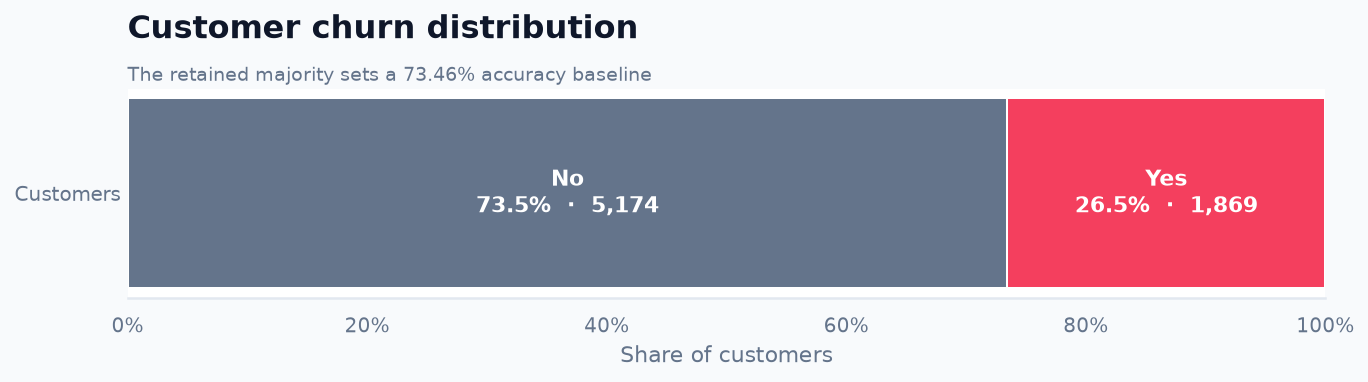

In [9]:
# Graph 1: target distribution
counts = analysis_df["Churn"].value_counts().reindex(["No", "Yes"])
shares = counts / counts.sum()

fig, ax = plt.subplots(figsize=(9.6, 2.8))
left = 0
for label in ["No", "Yes"]:
    value = shares[label]
    ax.barh(["Customers"], [value], left=left, height=0.42, color=CHURN_COLORS[label], label=label)
    ax.text(
        left + value / 2, 0,
        f"{label}\n{value:.1%}  ·  {counts[label]:,}",
        ha="center", va="center", color="white", fontweight="bold", fontsize=11,
    )
    left += value
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.set_xlabel("Share of customers")
ax.set_ylabel("")
polish_axis(
    ax, "Customer churn distribution",
    "The retained majority sets a 73.46% accuracy baseline",
    grid=None,
)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
finish_figure(fig)

> **Key finding:** Most customers remain. This establishes the 73.46%
> majority-class baseline that every useful model should exceed.

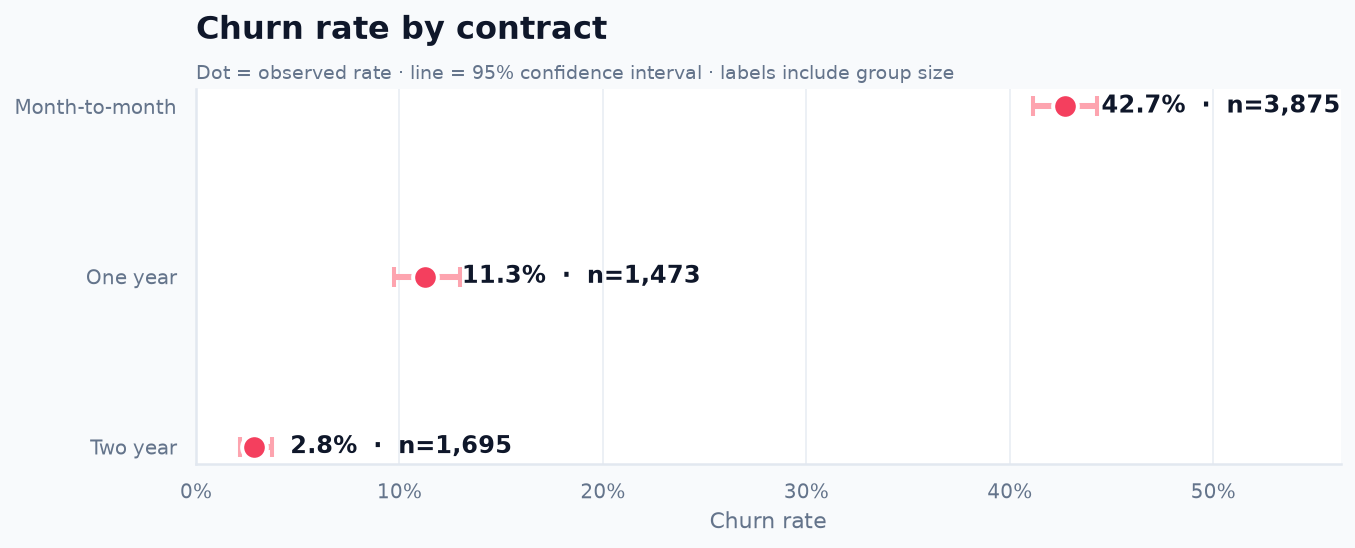

,customers,churners,churn_rate,ci_low,ci_high
Contract,,,,,
Month-to-month,3875,1655,42.71%,41.16%,44.27%
One year,1473,166,11.27%,9.75%,12.99%
Two year,1695,48,2.83%,2.14%,3.73%


In [10]:
# Graph 2: contract
contract_summary = plot_churn_rate(
    analysis_df, "Contract", "Churn rate by contract",
    order=["Month-to-month", "One year", "Two year"],
)
contract_summary.style.format({
    "churn_rate": "{:.2%}", "ci_low": "{:.2%}", "ci_high": "{:.2%}"
})

> **Key finding:** Month-to-month customers churn far more frequently
> than customers with longer commitments. The confidence intervals are narrow
> because every contract group contains many customers.

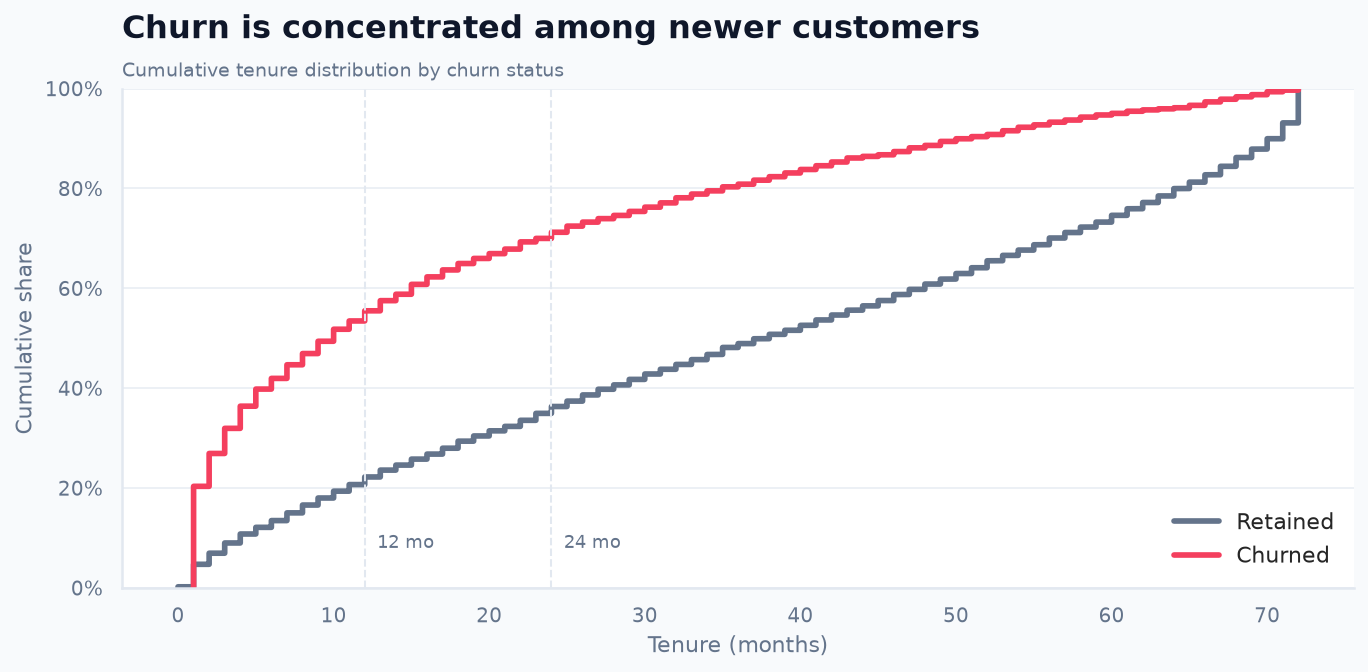

In [11]:
# Graph 3: tenure
fig, ax = plt.subplots(figsize=(9.6, 4.8))
for label in ["No", "Yes"]:
    sns.ecdfplot(
        data=analysis_df[analysis_df["Churn"].eq(label)],
        x="tenure", label=label, color=CHURN_COLORS[label],
        linewidth=2.8, ax=ax,
    )
for month in [12, 24]:
    ax.axvline(month, color=GRID, linestyle="--", linewidth=1)
    ax.text(month + 0.8, 0.08, f"{month} mo", color=MUTED, fontsize=9)
ax.set(xlabel="Tenure (months)", ylabel="Cumulative share")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
polish_axis(
    ax, "Churn is concentrated among newer customers",
    "Cumulative tenure distribution by churn status",
    grid="y",
)
ax.legend(title="", labels=["Retained", "Churned"], loc="lower right")
finish_figure(fig)

> **Key finding:** The churn curve rises much faster at low tenure, so
> many churners are relatively new customers. An ECDF avoids arbitrary histogram
> bins and motivates lifecycle features.

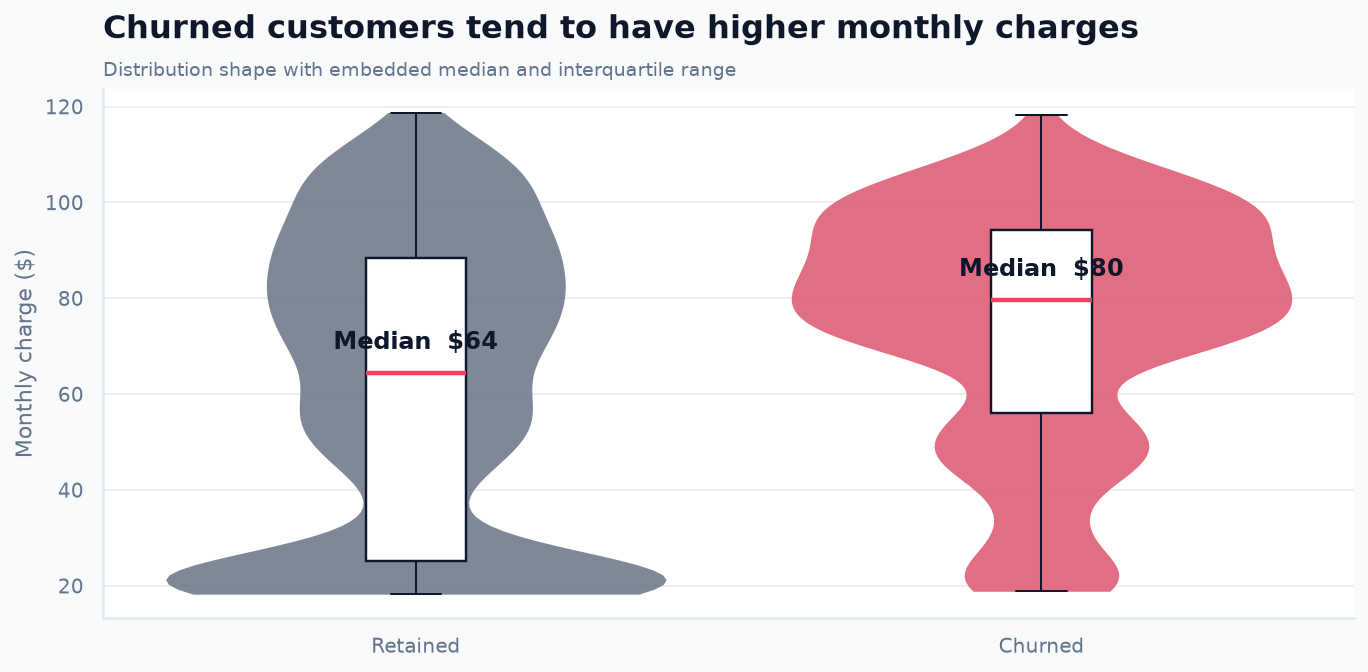

In [12]:
# Graph 4: monthly charges
fig, ax = plt.subplots(figsize=(9.6, 4.8))
sns.violinplot(
    data=analysis_df, x="Churn", y="MonthlyCharges", hue="Churn",
    order=["No", "Yes"], palette=CHURN_COLORS, legend=False,
    inner=None, cut=0, linewidth=0, alpha=0.86, ax=ax,
)
sns.boxplot(
    data=analysis_df, x="Churn", y="MonthlyCharges",
    order=["No", "Yes"], width=0.16, showfliers=False,
    boxprops={"facecolor": "white", "edgecolor": INK, "linewidth": 1.2},
    medianprops={"color": CORAL, "linewidth": 2.2},
    whiskerprops={"color": INK}, capprops={"color": INK}, ax=ax,
)
medians = analysis_df.groupby("Churn")["MonthlyCharges"].median().reindex(["No", "Yes"])
for position, (label, median) in enumerate(medians.items()):
    ax.text(position, median + 5, f"Median  ${median:,.0f}", ha="center", color=INK, fontweight="bold")
ax.set(xlabel="", ylabel="Monthly charge ($)")
ax.set_xticks([0, 1], labels=["Retained", "Churned"])
polish_axis(
    ax, "Churned customers tend to have higher monthly charges",
    "Distribution shape with embedded median and interquartile range",
    grid="y",
)
finish_figure(fig)

> **Key finding:** Churners tend to have higher monthly charges, but the
> distributions overlap substantially. Price is informative but cannot determine
> churn by itself.

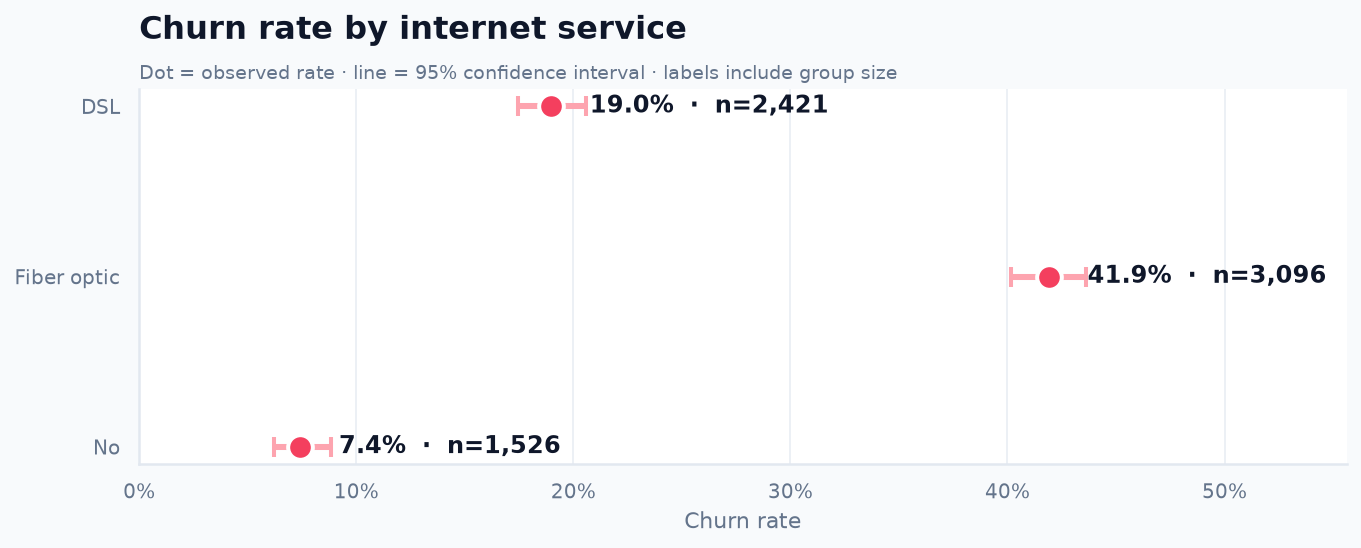

,customers,churners,churn_rate,ci_low,ci_high
InternetService,,,,,
DSL,2421,459,18.96%,17.45%,20.57%
Fiber optic,3096,1297,41.89%,40.17%,43.64%
No,1526,113,7.40%,6.20%,8.83%


In [13]:
# Graph 5: internet service
internet_summary = plot_churn_rate(
    analysis_df, "InternetService", "Churn rate by internet service",
    order=["DSL", "Fiber optic", "No"],
)
internet_summary.style.format({
    "churn_rate": "{:.2%}", "ci_low": "{:.2%}", "ci_high": "{:.2%}"
})

> **Key finding:** Fiber-optic customers have the highest observed churn.
> This is an association, not proof that fiber service causes churn; these
> customers also differ in price and service combinations.

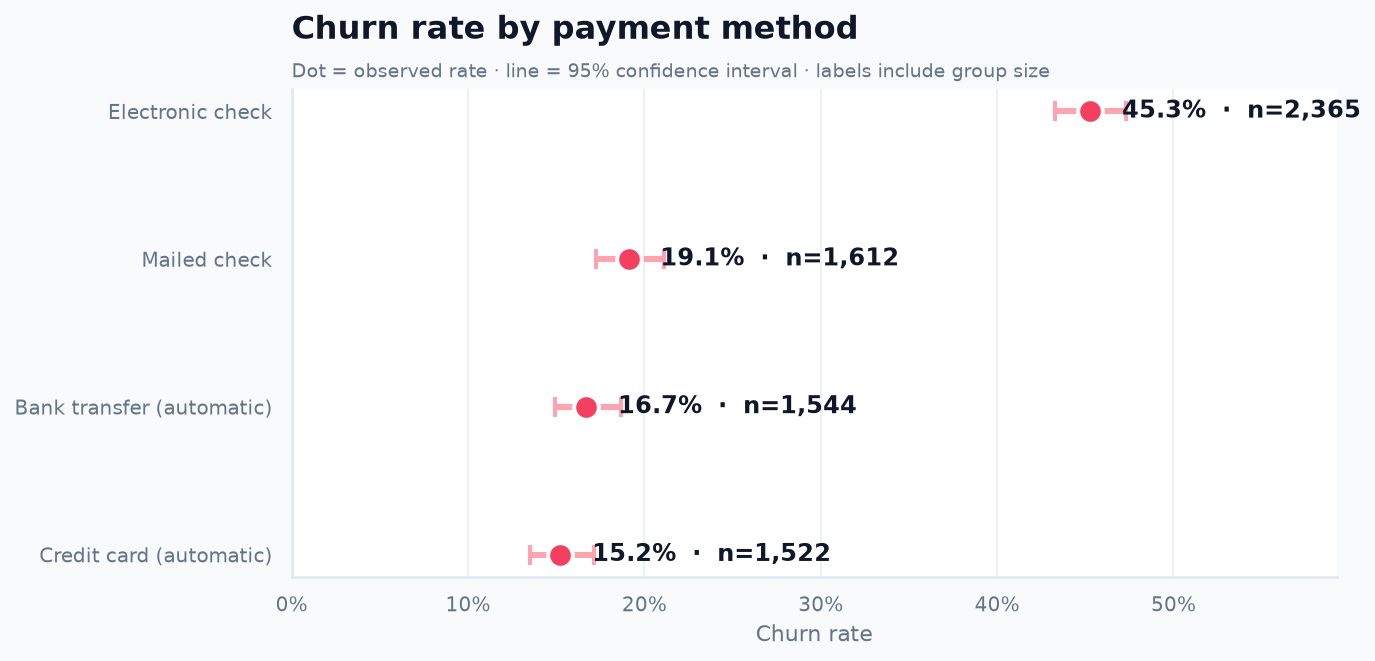

,customers,churners,churn_rate,ci_low,ci_high
PaymentMethod,,,,,
Electronic check,2365,1071,45.29%,43.29%,47.30%
Mailed check,1612,308,19.11%,17.26%,21.10%
Bank transfer (automatic),1544,258,16.71%,14.93%,18.65%
Credit card (automatic),1522,232,15.24%,13.52%,17.14%


In [14]:
# Graph 6: payment method
payment_order = [
    "Electronic check", "Mailed check",
    "Bank transfer (automatic)", "Credit card (automatic)",
]
payment_summary = plot_churn_rate(
    analysis_df, "PaymentMethod", "Churn rate by payment method",
    order=payment_order, horizontal=True,
)
payment_summary.style.format({
    "churn_rate": "{:.2%}", "ci_low": "{:.2%}", "ci_high": "{:.2%}"
})

> **Key finding:** Electronic-check customers have the highest churn
> rate, while automatic payment methods have lower rates. Payment method may
> reflect convenience, contract, or engagement differences rather than causation.

In [10]:
# examine gender 
churn1 = churn.copy()
dict_convert= {"Yes":1,"No":0}
new_churn_col = churn1.Churn.map(dict_convert).astype(int)
new_churn_col
churn1['Churn'] = new_churn_col
#check how many genders exists in the database
print(churn1.gender.unique())
churn1.groupby('gender').agg({'Churn':['count','sum','mean']})

<StringArray>
['Female', 'Male']
Length: 2, dtype: str


Churn               
       count  sum      mean
gender                     
Female  3488  939  0.269209
Male    3555  930  0.261603

**Gender does not have an impact churn rate**

               Churn_mean  MonthlyCharges_mean  tenure_mean
SeniorCitizen                                              
0                0.236062            61.847441    32.192171
1                0.416813            79.820359    33.295972
Index(['Non senior', 'Senior'], dtype='str', name='SeniorCitizen')


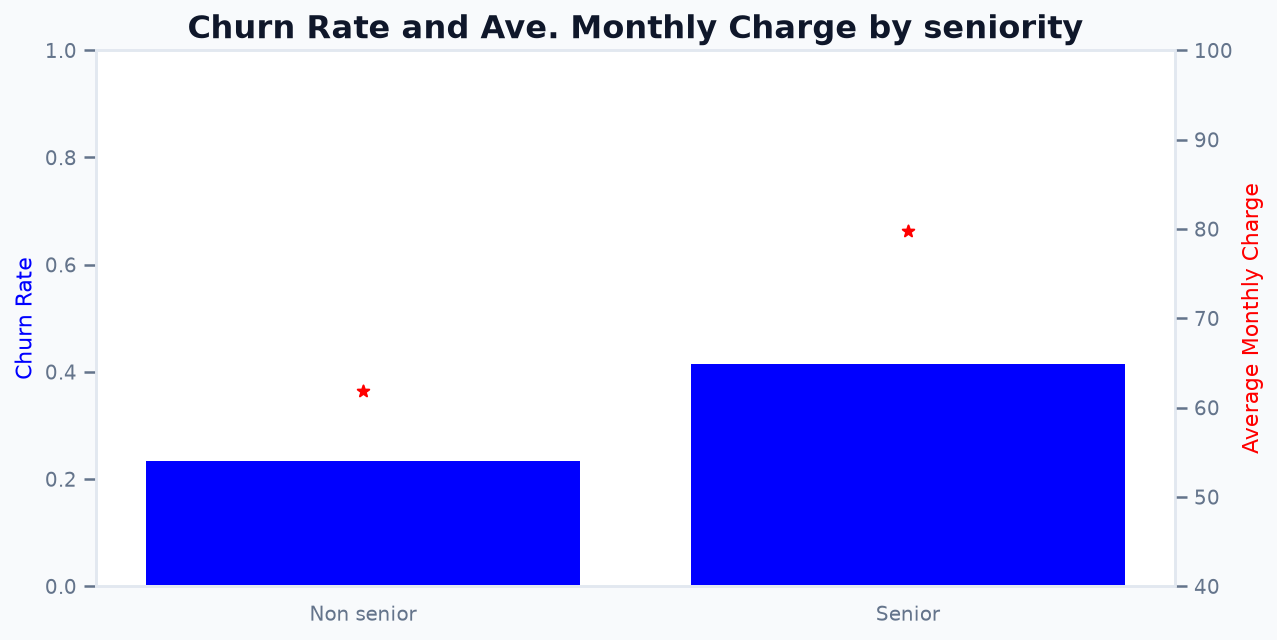

In [81]:
#senior citizen attribute
sc_churn = churn1.groupby('SeniorCitizen').agg({'Churn':['mean'],'MonthlyCharges': ['mean'],'tenure': ['mean']})
colname = [col+'_'+i for col,i  in sc_churn.columns]
colname
sc_churn.columns =colname
print(sc_churn)
sc_churn.rename(index ={0:'Non senior',1:'Senior'}, inplace = True)
xaxis = sc_churn.index
print(xaxis)
fig, ax1 = plt.subplots()

# Plot first data set on left y-axis
ax1.bar(xaxis, sc_churn.Churn_mean, color='blue', label='Sine')
ax1.set_ylabel('Churn Rate', color='blue')
ax1.set_ylim(0, 1)  

# Create secondary y-axis sharing the same x-axis
ax2 = ax1.twinx()

# Plot second data set on right y-axis
ax2.scatter(xaxis, sc_churn.MonthlyCharges_mean, color='red', marker= '*' )
ax2.set_ylabel('Average Monthly Charge', color='red')
ax2.set_ylim(40, 100)  
plt.title("Churn Rate and Ave. Monthly Charge by seniority")

plt.show()


Conclusion: Senior citizens are more prone to churn 

In [4]:
# Checking whether tenure has an impact on churning chances
# I imported the CSV into a new df, because a lot has changed.
churnT = pd.read_csv(DATA_PATH)
churnT.head()

NameError: name 'pd' is not defined

## 5. Data engineering

Engineering decisions are limited to features with a simple domain explanation:

- Remove `customerID` because it is a unique identifier.
- Convert `TotalCharges` to numeric and set the 11 zero-tenure blanks to zero.
- Add `NewCustomer` for zero tenure.
- Add `TenureGroup` to represent lifecycle stages.
- Separate service adoption into connectivity, support/security, and entertainment counts rather than treating every service as equivalent.
- Add `AutomaticPayment`.
- Add `NewMonthToMonth`, a focused interaction supported by the strong tenure and contract patterns.

The original columns are retained so grouped features summarize rather than replace detailed information.

In [15]:
model_df = churn.copy()
model_df["TotalCharges"] = pd.to_numeric(model_df["TotalCharges"], errors="coerce")
model_df.loc[
    model_df["TotalCharges"].isna() & model_df["tenure"].eq(0),
    "TotalCharges",
] = 0

model_df["NewCustomer"] = model_df["tenure"].eq(0).astype(int)
model_df["TenureGroup"] = pd.cut(
    model_df["tenure"],
    bins=[-1, 12, 24, 48, np.inf],
    labels=["0-12 months", "13-24 months", "25-48 months", "49+ months"],
)
model_df["ConnectivityServiceCount"] = (
    model_df["PhoneService"].eq("Yes").astype(int)
    + model_df["MultipleLines"].eq("Yes").astype(int)
    + model_df["InternetService"].ne("No").astype(int)
)
model_df["SupportServiceCount"] = model_df[[
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
]].eq("Yes").sum(axis=1)
model_df["EntertainmentServiceCount"] = model_df[[
    "StreamingTV", "StreamingMovies",
]].eq("Yes").sum(axis=1)
model_df["AutomaticPayment"] = model_df["PaymentMethod"].str.contains(
    "automatic", case=False
).astype(int)
model_df["NewMonthToMonth"] = (
    model_df["tenure"].le(12) & model_df["Contract"].eq("Month-to-month")
).astype(int)

y = model_df["Churn"].map({"No": 0, "Yes": 1})
X_original = model_df.drop(columns=[
    "customerID", "Churn", "NewCustomer", "TenureGroup",
    "ConnectivityServiceCount", "SupportServiceCount",
    "EntertainmentServiceCount", "AutomaticPayment", "NewMonthToMonth",
])
X_simple = model_df.drop(columns=[
    "customerID", "Churn", "ConnectivityServiceCount", "SupportServiceCount",
    "EntertainmentServiceCount", "AutomaticPayment", "NewMonthToMonth",
])
X = model_df.drop(columns=["customerID", "Churn"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
train_indices, test_indices = X_train.index, X_test.index

split_summary = pd.DataFrame({
    "examples": [len(X_train), len(X_test)],
    "non_churn": [(y_train == 0).sum(), (y_test == 0).sum()],
    "churn": [(y_train == 1).sum(), (y_test == 1).sum()],
    "churn_rate": [y_train.mean(), y_test.mean()],
}, index=["train", "test"])
split_summary.style.format({"churn_rate": "{:.2%}"})

,examples,non_churn,churn,churn_rate
train,5634,4139,1495,26.54%
test,1409,1035,374,26.54%


> **Why this decision?** The stratified 80/20 split reserves 1,409
> customers for one final evaluation while preserving the churn rate. All
> parameter and feature decisions use cross-validation on training rows only;
> the test set remains untouched until the final comparison.

In [16]:
def make_preprocessor(frame, scale_numeric=False):
    numeric_features = frame.select_dtypes(include="number").columns.tolist()
    categorical_features = frame.select_dtypes(exclude="number").columns.tolist()
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numeric_features),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ])

validation_preprocessor = make_preprocessor(X_train, scale_numeric=True)
X_train_transformed = validation_preprocessor.fit_transform(X_train)
X_test_transformed = validation_preprocessor.transform(X_test)

print("Training matrix:", X_train_transformed.shape)
print("Test matrix:", X_test_transformed.shape)
print("Numeric matrix:", np.issubdtype(X_train_transformed.dtype, np.number))
print("Training missing values:", np.isnan(X_train_transformed).sum())
print("Test missing values:", np.isnan(X_test_transformed).sum())

Training matrix: (5634, 55)
Test matrix: (1409, 55)
Numeric matrix: True
Training missing values: 0
Test missing values: 0


> **Why this decision?** Preprocessing stays inside every pipeline, so
> medians, categories, and scaling are learned independently within each training
> fold. This prevents validation or test information from leaking into fitting.

### Engineered-feature ablation

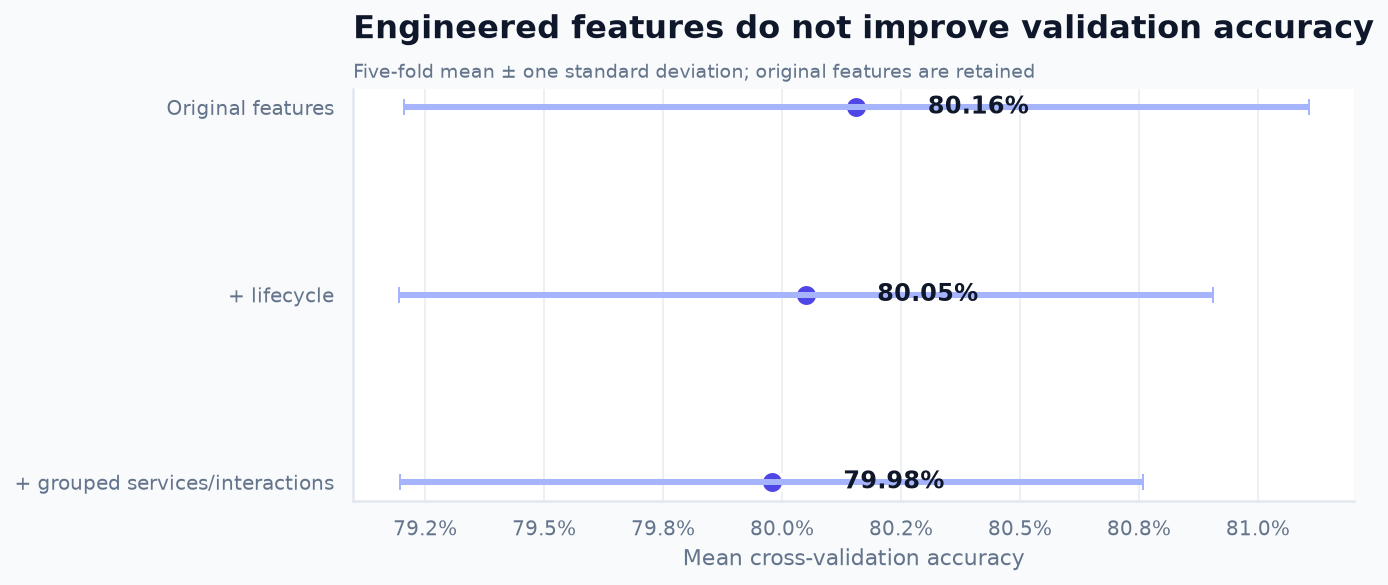

,cv_accuracy_mean,cv_accuracy_std
feature_set,,
Original features,0.8016,0.0095
+ lifecycle,0.8005,0.0086
+ grouped services/interactions,0.7998,0.0078


In [17]:
ablation_sets = {
    "Original features": X_original,
    "+ lifecycle": X_simple,
    "+ grouped services/interactions": X,
}
ablation_rows = []
for name, frame in ablation_sets.items():
    frame_train = frame.loc[train_indices]
    estimator = Pipeline([
        ("preprocessor", make_preprocessor(frame_train)),
        ("model", RandomForestClassifier(
            n_estimators=100, max_depth=6,
            random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])
    scores = cross_validate(
        estimator, frame_train, y_train, cv=CV,
        scoring="accuracy", n_jobs=-1,
    )["test_score"]
    ablation_rows.append({
        "feature_set": name,
        "cv_accuracy_mean": scores.mean(),
        "cv_accuracy_std": scores.std(),
    })

ablation_results = pd.DataFrame(ablation_rows).set_index("feature_set")
plot_data = ablation_results.sort_values("cv_accuracy_mean")
fig, ax = plt.subplots(figsize=(9.6, 4.2))
positions = np.arange(len(plot_data))
ax.errorbar(
    plot_data["cv_accuracy_mean"], positions,
    xerr=plot_data["cv_accuracy_std"],
    fmt="none", ecolor="#A5B4FC", elinewidth=3, capsize=4,
)
ax.scatter(plot_data["cv_accuracy_mean"], positions, s=130, color=PRIMARY, edgecolor="white", linewidth=2)
ax.set_yticks(positions, plot_data.index)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1%}"))
ax.set(xlabel="Mean cross-validation accuracy", ylabel="")
polish_axis(
    ax, "Engineered features do not improve validation accuracy",
    "Five-fold mean ± one standard deviation; original features are retained",
    grid="x",
)
for y, value in zip(positions, plot_data["cv_accuracy_mean"]):
    ax.text(value + 0.0015, y, f"{value:.2%}", va="center", color=INK, fontweight="bold")
finish_figure(fig)
ablation_results.style.format("{:.4f}")

> **Why this decision?** Ablation tests whether engineered feature groups
> help under the same model and folds. Only the feature set with the strongest
> mean validation accuracy proceeds to the required algorithm searches.

In [18]:
feature_frames = {
    "Original features": X_original,
    "+ lifecycle": X_simple,
    "+ grouped services/interactions": X,
}
selected_feature_set = ablation_results["cv_accuracy_mean"].idxmax()
selected_frame = feature_frames[selected_feature_set]
X_train = selected_frame.loc[train_indices]
X_test = selected_frame.loc[test_indices]

print("Selected feature set:", selected_feature_set)
print("Model input columns:", X_train.shape[1])

Selected feature set: Original features
Model input columns: 19


Feature engineering remains documented because the reasoning is useful, but the final model input follows validation evidence. Features that fail to improve the controlled ablation are rejected rather than kept by assumption.

## 6. Evaluation design and majority baseline

In [19]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
baseline_train_accuracy = dummy.score(X_train, y_train)
baseline_test_accuracy = dummy.score(X_test, y_test)
pd.DataFrame({
    "train_accuracy": [baseline_train_accuracy],
    "test_accuracy": [baseline_test_accuracy],
}, index=["Majority baseline"]).style.format("{:.4f}")

,train_accuracy,test_accuracy
Majority baseline,0.7346,0.7346


The majority baseline predicts that every customer remains. It provides a minimum reference for accuracy. Model hyperparameters are selected by mean five-fold training-set validation accuracy, while fold standard deviation shows stability. The test set is evaluated only after all three searches finish.

## 7. K-nearest neighbors

KNN predicts from nearby customers. Scaling is required because distance would otherwise be dominated by large numeric ranges. `k`, neighbor weighting, and Manhattan/Euclidean distance are tuned; odd `k` values reduce voting ties.

In [20]:
knn_pipeline = Pipeline([
    ("preprocessor", make_preprocessor(X_train, scale_numeric=True)),
    ("model", KNeighborsClassifier()),
])
knn_search = GridSearchCV(
    knn_pipeline,
    param_grid={
        "model__n_neighbors": [5, 11, 21, 31],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
    scoring="accuracy", cv=CV, n_jobs=-1, return_train_score=True,
)
knn_search.fit(X_train, y_train)
best_knn = knn_search.best_estimator_
print("Best KNN parameters:", knn_search.best_params_)
print(f"Best mean CV accuracy: {knn_search.best_score_:.4f}")

Best KNN parameters: {'model__n_neighbors': 31, 'model__p': 1, 'model__weights': 'uniform'}
Best mean CV accuracy: 0.7945


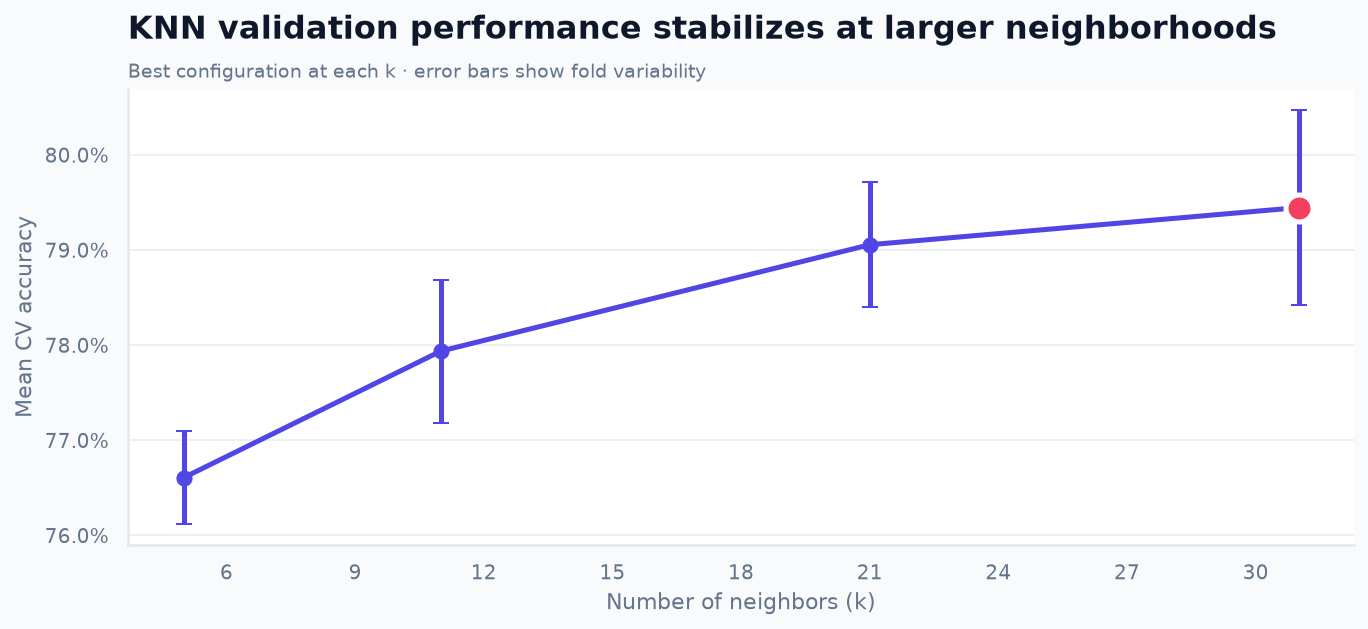

,param_model__n_neighbors,param_model__weights,param_model__p,mean_train_score,mean_test_score,std_test_score
12,31,uniform,1,0.8091,0.7945,0.0103
10,21,uniform,2,0.8098,0.7906,0.0066
14,31,uniform,2,0.8061,0.7888,0.0100
8,21,uniform,1,0.8098,0.7881,0.0064
13,31,distance,1,0.9983,0.7826,0.0084
15,31,distance,2,0.9984,0.7801,0.0098
11,21,distance,2,0.9984,0.7796,0.0051
6,11,uniform,2,0.8180,0.7794,0.0075


In [21]:
knn_cv = pd.DataFrame(knn_search.cv_results_)
knn_by_k = (
    knn_cv.sort_values("mean_test_score", ascending=False)
    .groupby("param_model__n_neighbors", as_index=False)
    .first()
    .sort_values("param_model__n_neighbors")
)
fig, ax = plt.subplots(figsize=(9.6, 4.5))
ax.errorbar(
    knn_by_k["param_model__n_neighbors"], knn_by_k["mean_test_score"],
    yerr=knn_by_k["std_test_score"], color=PRIMARY, linewidth=2.5,
    marker="o", markersize=7, capsize=4,
)
best_point = knn_by_k.loc[knn_by_k["mean_test_score"].idxmax()]
ax.scatter(
    best_point["param_model__n_neighbors"], best_point["mean_test_score"],
    s=180, color=CORAL, edgecolor="white", linewidth=2.5, zorder=4,
)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1%}"))
ax.set(xlabel="Number of neighbors (k)", ylabel="Mean CV accuracy")
polish_axis(
    ax, "KNN validation performance stabilizes at larger neighborhoods",
    "Best configuration at each k · error bars show fold variability",
    grid="y",
)
finish_figure(fig)
knn_cv[[
    "param_model__n_neighbors", "param_model__weights", "param_model__p",
    "mean_train_score", "mean_test_score", "std_test_score",
]].sort_values("mean_test_score", ascending=False).head(8).style.format({
    "mean_train_score": "{:.4f}", "mean_test_score": "{:.4f}", "std_test_score": "{:.4f}"
})

Small neighborhoods fit local details more strongly; larger neighborhoods smooth the boundary. The fold error bars show whether small differences are stable rather than artifacts of one split.

## 8. Decision tree

Decision trees provide readable nonlinear rules. Depth, leaf size, split criterion, and pruning are tuned because unrestricted growth can memorize training customers.

In [22]:
tree_pipeline = Pipeline([
    ("preprocessor", make_preprocessor(X_train)),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])
tree_search = GridSearchCV(
    tree_pipeline,
    param_grid={
        "model__max_depth": [2, 3, 4, 5, 6, 8, None],
        "model__min_samples_leaf": [1, 5, 10],
        "model__criterion": ["gini", "entropy"],
        "model__ccp_alpha": [0.0, 0.001],
    },
    scoring="accuracy", cv=CV, n_jobs=-1, return_train_score=True,
)
tree_search.fit(X_train, y_train)
best_tree = tree_search.best_estimator_
print("Best decision-tree parameters:", tree_search.best_params_)
print(f"Best mean CV accuracy: {tree_search.best_score_:.4f}")

Best decision-tree parameters: {'model__ccp_alpha': 0.0, 'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 5}
Best mean CV accuracy: 0.7938


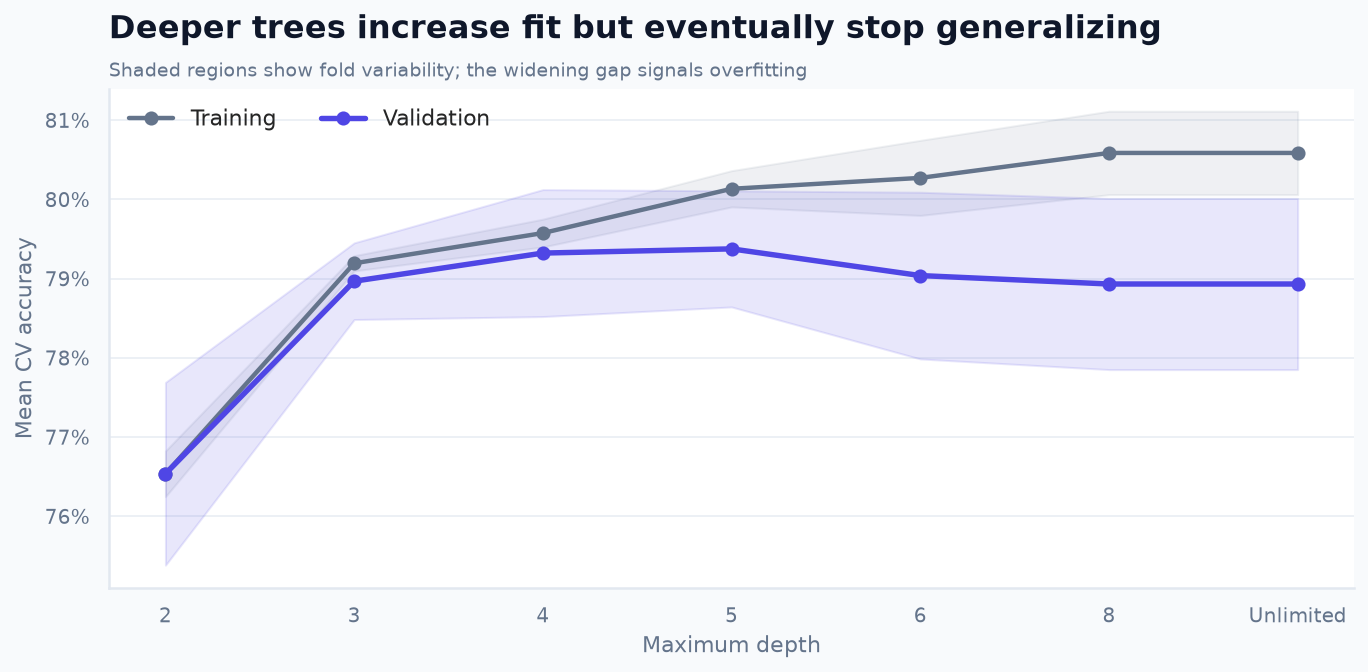

In [23]:
tree_cv = pd.DataFrame(tree_search.cv_results_)
tree_cv["depth_label"] = tree_cv["param_model__max_depth"].astype(str).replace("None", "Unlimited")
tree_by_depth = (
    tree_cv.sort_values("mean_test_score", ascending=False)
    .groupby("depth_label", as_index=False)
    .first()
)
depth_order = ["2", "3", "4", "5", "6", "8", "Unlimited"]
tree_by_depth["depth_label"] = pd.Categorical(tree_by_depth["depth_label"], depth_order, ordered=True)
tree_by_depth = tree_by_depth.sort_values("depth_label")

fig, ax = plt.subplots(figsize=(9.6, 4.8))
x = np.arange(len(tree_by_depth))
ax.plot(x, tree_by_depth["mean_train_score"], color=SLATE, linewidth=2.2, marker="o", label="Training")
ax.fill_between(
    x,
    tree_by_depth["mean_train_score"] - tree_by_depth["std_train_score"],
    tree_by_depth["mean_train_score"] + tree_by_depth["std_train_score"],
    color=SLATE, alpha=0.10,
)
ax.plot(x, tree_by_depth["mean_test_score"], color=PRIMARY, linewidth=2.7, marker="o", label="Validation")
ax.fill_between(
    x,
    tree_by_depth["mean_test_score"] - tree_by_depth["std_test_score"],
    tree_by_depth["mean_test_score"] + tree_by_depth["std_test_score"],
    color=PRIMARY, alpha=0.13,
)
ax.set_xticks(x, tree_by_depth["depth_label"].astype(str))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.set(xlabel="Maximum depth", ylabel="Mean CV accuracy")
polish_axis(
    ax, "Deeper trees increase fit but eventually stop generalizing",
    "Shaded regions show fold variability; the widening gap signals overfitting",
    grid="y",
)
ax.legend(loc="upper left", ncol=2)
finish_figure(fig)

A widening training/validation gap indicates overfitting. The selected tree is the configuration with the highest mean validation accuracy, not the deepest tree.

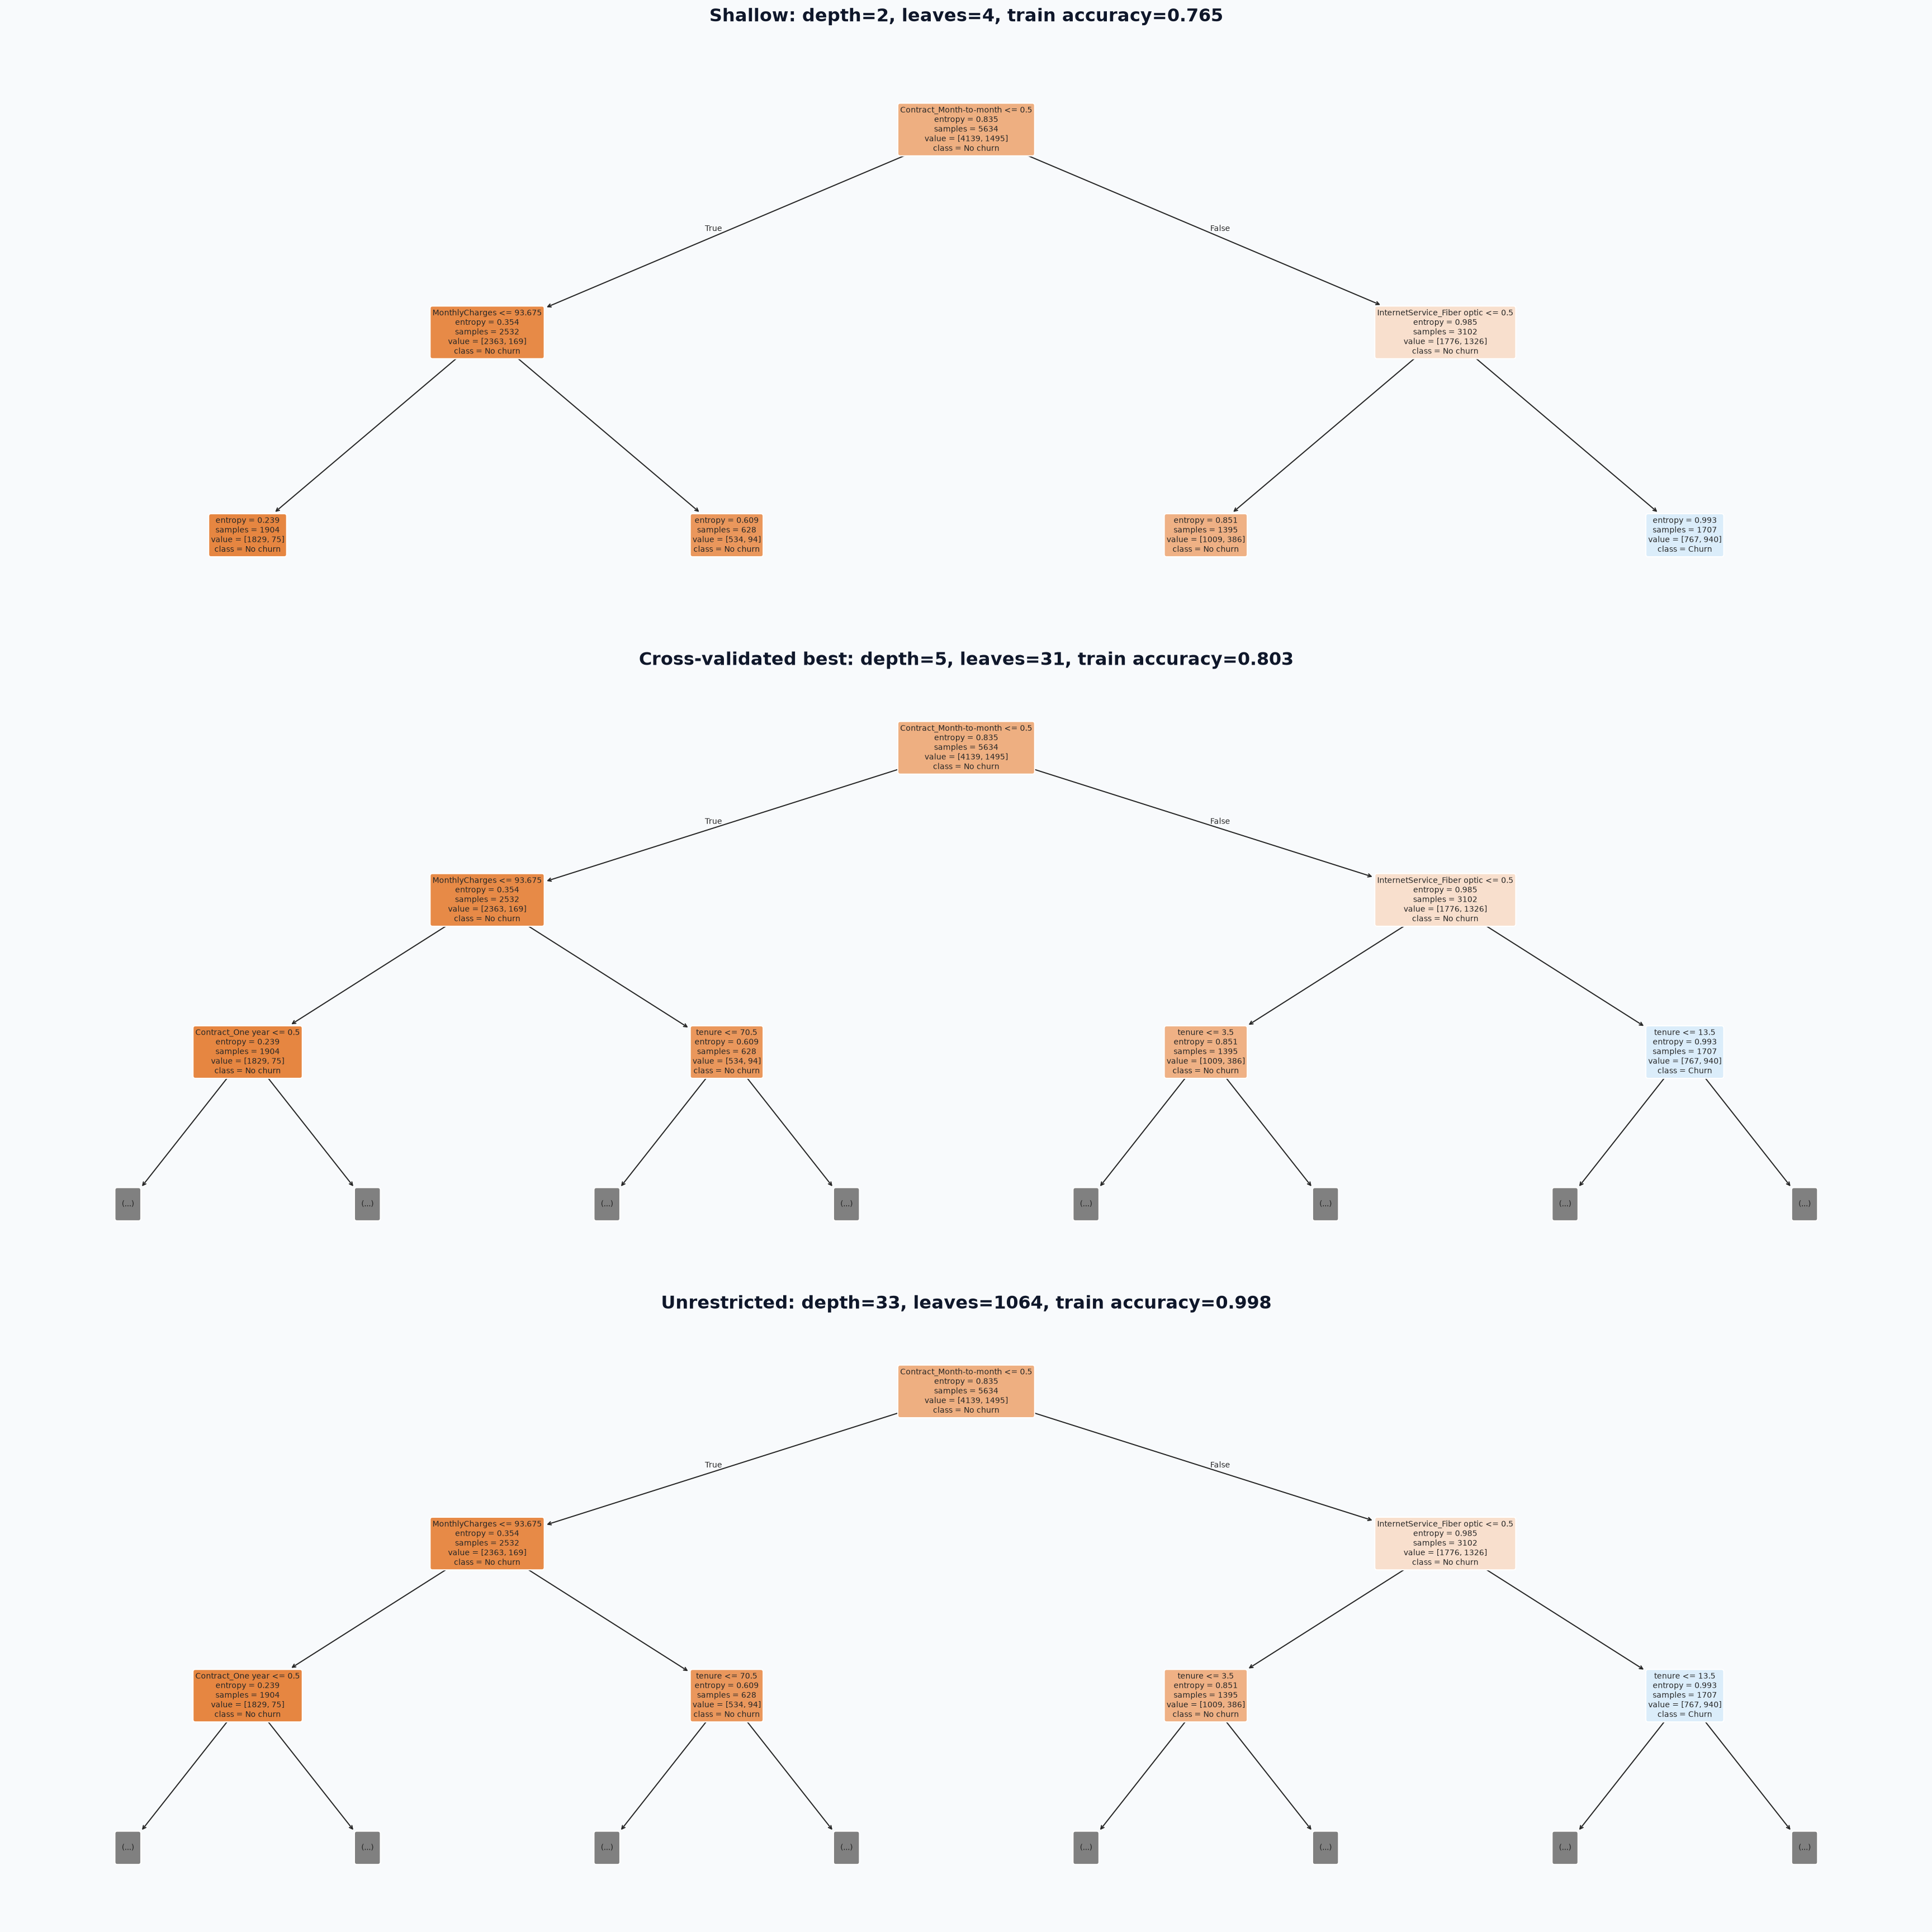

In [24]:
shallow_tree = clone(best_tree).set_params(model__max_depth=2, model__ccp_alpha=0.0)
unrestricted_tree = clone(best_tree).set_params(model__max_depth=None, model__ccp_alpha=0.0, model__min_samples_leaf=1)
shallow_tree.fit(X_train, y_train)
unrestricted_tree.fit(X_train, y_train)

tree_artifacts = [
    ("Shallow", shallow_tree),
    ("Cross-validated best", best_tree),
    ("Unrestricted", unrestricted_tree),
]
feature_names = best_tree.named_steps["preprocessor"].get_feature_names_out()
feature_names = [name.replace("numeric__", "").replace("categorical__", "") for name in feature_names]

fig, axes = plt.subplots(3, 1, figsize=(24, 24))
for ax, (label, estimator) in zip(axes, tree_artifacts):
    model = estimator.named_steps["model"]
    plot_tree(
        model, feature_names=feature_names,
        class_names=["No churn", "Churn"],
        filled=True, rounded=True, max_depth=2, fontsize=7, ax=ax,
    )
    ax.set_title(
        f"{label}: depth={model.get_depth()}, leaves={model.get_n_leaves()}, "
        f"train accuracy={estimator.score(X_train, y_train):.3f}"
    )
plt.tight_layout()
plt.show()

The shallow tree is readable but limited, the selected tree balances validation fit and complexity, and the unrestricted tree demonstrates how rapidly the artifact can grow and overfit. Only the first three visible levels are drawn for readability.

## 9. Random forest

A random forest averages many randomized trees to reduce single-tree instability. The required depth and estimator counts are crossed with maximum-feature and minimum-leaf choices. The heatmap displays the best validation result for every required depth/estimator pair.

In [25]:
forest_pipeline = Pipeline([
    ("preprocessor", make_preprocessor(X_train)),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])
forest_search = GridSearchCV(
    forest_pipeline,
    param_grid={
        "model__max_depth": [4, 6, 8, None],
        "model__n_estimators": [50, 100, 200],
        "model__max_features": ["sqrt", 0.5],
        "model__min_samples_leaf": [1, 3],
    },
    scoring="accuracy", cv=CV, n_jobs=-1, return_train_score=True,
)
forest_search.fit(X_train, y_train)
best_forest = forest_search.best_estimator_
print("Best random-forest parameters:", forest_search.best_params_)
print(f"Best mean CV accuracy: {forest_search.best_score_:.4f}")

Best random-forest parameters: {'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best mean CV accuracy: 0.8042


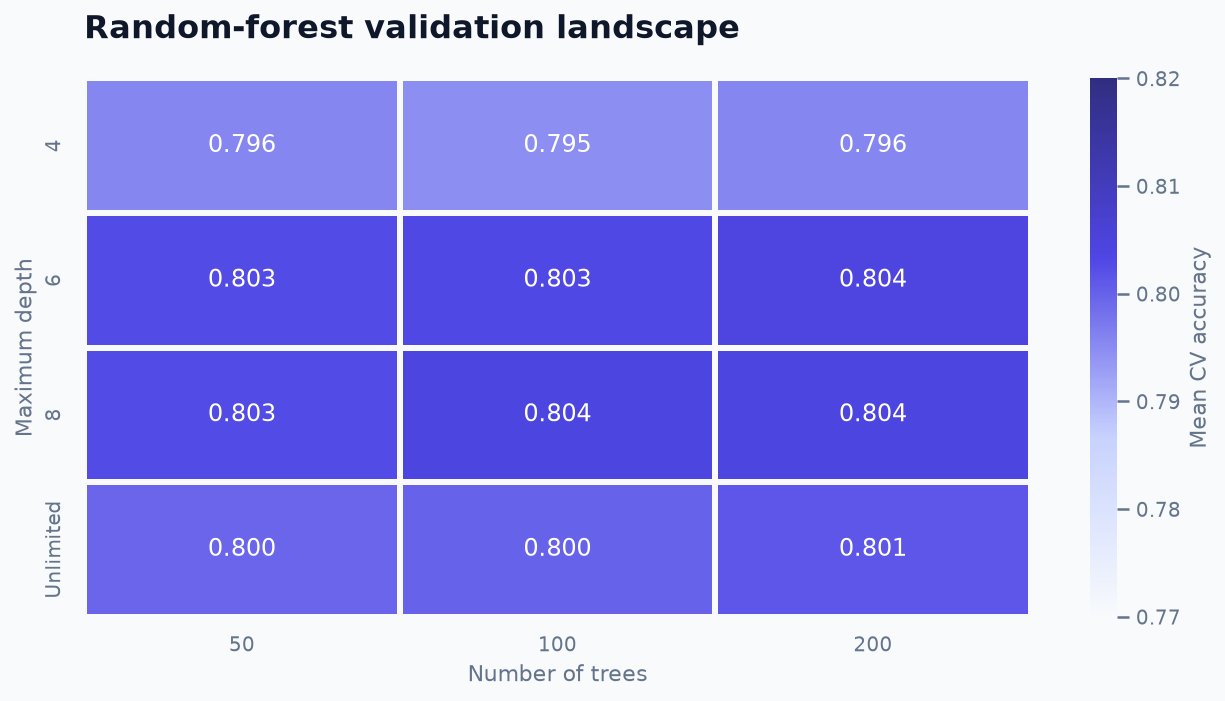

,param_model__max_depth,param_model__n_estimators,param_model__max_features,param_model__min_samples_leaf,mean_train_score,mean_test_score,std_test_score
26,8,200,sqrt,1,0.8393,0.8042,0.0090
29,8,200,sqrt,3,0.8347,0.8042,0.0084
28,8,100,sqrt,3,0.8344,0.8042,0.0069
23,6,200,0.500000,3,0.8235,0.8040,0.0111
25,8,100,sqrt,1,0.8400,0.8037,0.0102
34,8,100,0.500000,3,0.8544,0.8037,0.0114
22,6,100,0.500000,3,0.8236,0.8032,0.0118
32,8,200,0.500000,1,0.8616,0.8030,0.0106
21,6,50,0.500000,3,0.8237,0.8028,0.0108
20,6,200,0.500000,1,0.8244,0.8028,0.0083


In [26]:
forest_cv = pd.DataFrame(forest_search.cv_results_)
forest_cv["depth_label"] = forest_cv["param_model__max_depth"].astype(str).replace("None", "Unlimited")
forest_pair_best = (
    forest_cv.sort_values("mean_test_score", ascending=False)
    .groupby(["depth_label", "param_model__n_estimators"], as_index=False)
    .first()
)
forest_grid = forest_pair_best.pivot(
    index="depth_label", columns="param_model__n_estimators", values="mean_test_score"
).reindex(["4", "6", "8", "Unlimited"])

plt.figure(figsize=(9, 5))
sns.heatmap(forest_grid, annot=True, fmt=".3f", cmap=INDIGO_CMAP, vmin=0.77, vmax=0.82, linewidths=2, linecolor=CANVAS, cbar_kws={"label": "Mean CV accuracy"})
plt.title("Random-forest validation landscape", loc="left", pad=20, color=INK, fontweight="bold")
plt.xlabel("Number of trees")
plt.ylabel("Maximum depth")
finish_figure(plt.gcf())
forest_cv[[
    "param_model__max_depth", "param_model__n_estimators",
    "param_model__max_features", "param_model__min_samples_leaf",
    "mean_train_score", "mean_test_score", "std_test_score",
]].sort_values("mean_test_score", ascending=False).head(10).style.format({
    "mean_train_score": "{:.4f}", "mean_test_score": "{:.4f}", "std_test_score": "{:.4f}"
})

More trees stabilize an ensemble but do not guarantee a higher score. Greater depth raises training fit; validation determines whether the added complexity generalizes.

## 10. Final untouched-test evaluation

Only now are the selected pipelines evaluated on the held-out customers. Accuracy is the required comparison metric; the additional metrics reveal errors hidden by class imbalance.

In [27]:
selected_models = {
    "KNN": best_knn,
    "Decision tree": best_tree,
    "Random forest": best_forest,
}
metric_rows = []
predictions = {}
for name, estimator in selected_models.items():
    train_prediction = estimator.predict(X_train)
    test_prediction = estimator.predict(X_test)
    test_probability = estimator.predict_proba(X_test)[:, 1]
    predictions[name] = test_prediction
    metric_rows.append({
        "algorithm": name,
        "train_accuracy": accuracy_score(y_train, train_prediction),
        "test_accuracy": accuracy_score(y_test, test_prediction),
        "balanced_accuracy": balanced_accuracy_score(y_test, test_prediction),
        "churn_precision": precision_score(y_test, test_prediction),
        "churn_recall": recall_score(y_test, test_prediction),
        "churn_f1": f1_score(y_test, test_prediction),
        "roc_auc": roc_auc_score(y_test, test_probability),
        "pr_auc": average_precision_score(y_test, test_probability),
        "mcc": matthews_corrcoef(y_test, test_prediction),
    })

final_metrics = pd.DataFrame(metric_rows).set_index("algorithm")
final_metrics.style.format("{:.4f}")

,train_accuracy,test_accuracy,balanced_accuracy,churn_precision,churn_recall,churn_f1,roc_auc,pr_auc,mcc
algorithm,,,,,,,,,
KNN,0.8085,0.7842,0.7199,0.5956,0.5829,0.5892,0.8269,0.6089,0.4430
Decision tree,0.8028,0.7984,0.7245,0.6347,0.5668,0.5989,0.8327,0.6233,0.4662
Random forest,0.8348,0.8070,0.7124,0.6821,0.5107,0.5841,0.8414,0.6578,0.4700


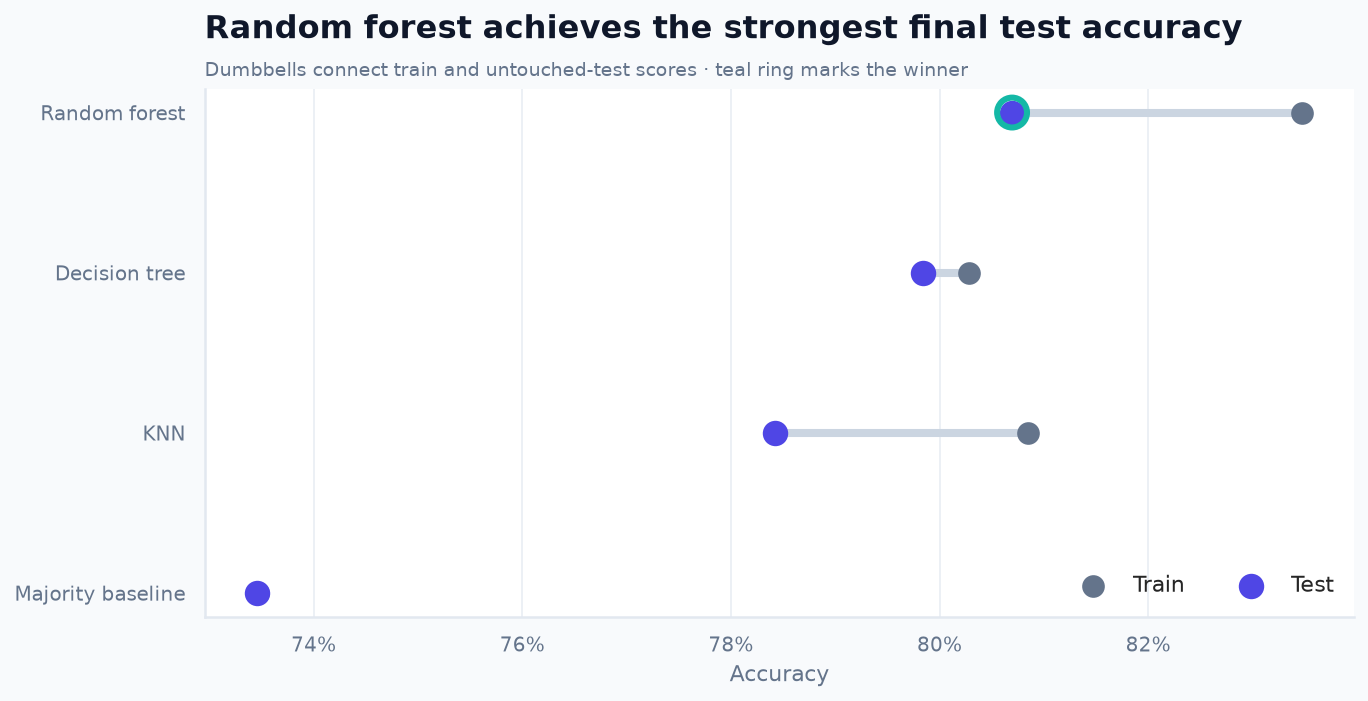

,train_accuracy,test_accuracy
Majority baseline,0.7346,0.7346
KNN,0.8085,0.7842
Decision tree,0.8028,0.7984
Random forest,0.8348,0.8070


In [28]:
accuracy_comparison = pd.concat([
    pd.DataFrame({
        "train_accuracy": [baseline_train_accuracy],
        "test_accuracy": [baseline_test_accuracy],
    }, index=["Majority baseline"]),
    final_metrics[["train_accuracy", "test_accuracy"]],
])
plot_accuracy = accuracy_comparison.sort_values("test_accuracy")
fig, ax = plt.subplots(figsize=(9.6, 5.0))
positions = np.arange(len(plot_accuracy))
for y, (_, row) in zip(positions, plot_accuracy.iterrows()):
    ax.plot(
        [row["test_accuracy"], row["train_accuracy"]], [y, y],
        color="#CBD5E1", linewidth=4, solid_capstyle="round",
    )
ax.scatter(plot_accuracy["train_accuracy"], positions, s=105, color=SLATE, label="Train", zorder=3)
ax.scatter(plot_accuracy["test_accuracy"], positions, s=135, color=PRIMARY, label="Test", zorder=4)
winner_y = list(plot_accuracy.index).index(final_metrics["test_accuracy"].idxmax())
ax.scatter(
    plot_accuracy.iloc[winner_y]["test_accuracy"], winner_y,
    s=220, facecolor="none", edgecolor=TEAL, linewidth=3, zorder=5,
)
ax.set_yticks(positions, plot_accuracy.index)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.set(xlabel="Accuracy", ylabel="")
polish_axis(
    ax, "Random forest achieves the strongest final test accuracy",
    "Dumbbells connect train and untouched-test scores · teal ring marks the winner",
    grid="x",
)
ax.legend(loc="lower right", ncol=2)
finish_figure(fig)
accuracy_comparison.style.format("{:.4f}")

> **Key finding:** The majority baseline gives the model scores context.
> The selected model has the highest untouched-test accuracy; train/test gaps
> help reveal overfitting but do not replace final performance.

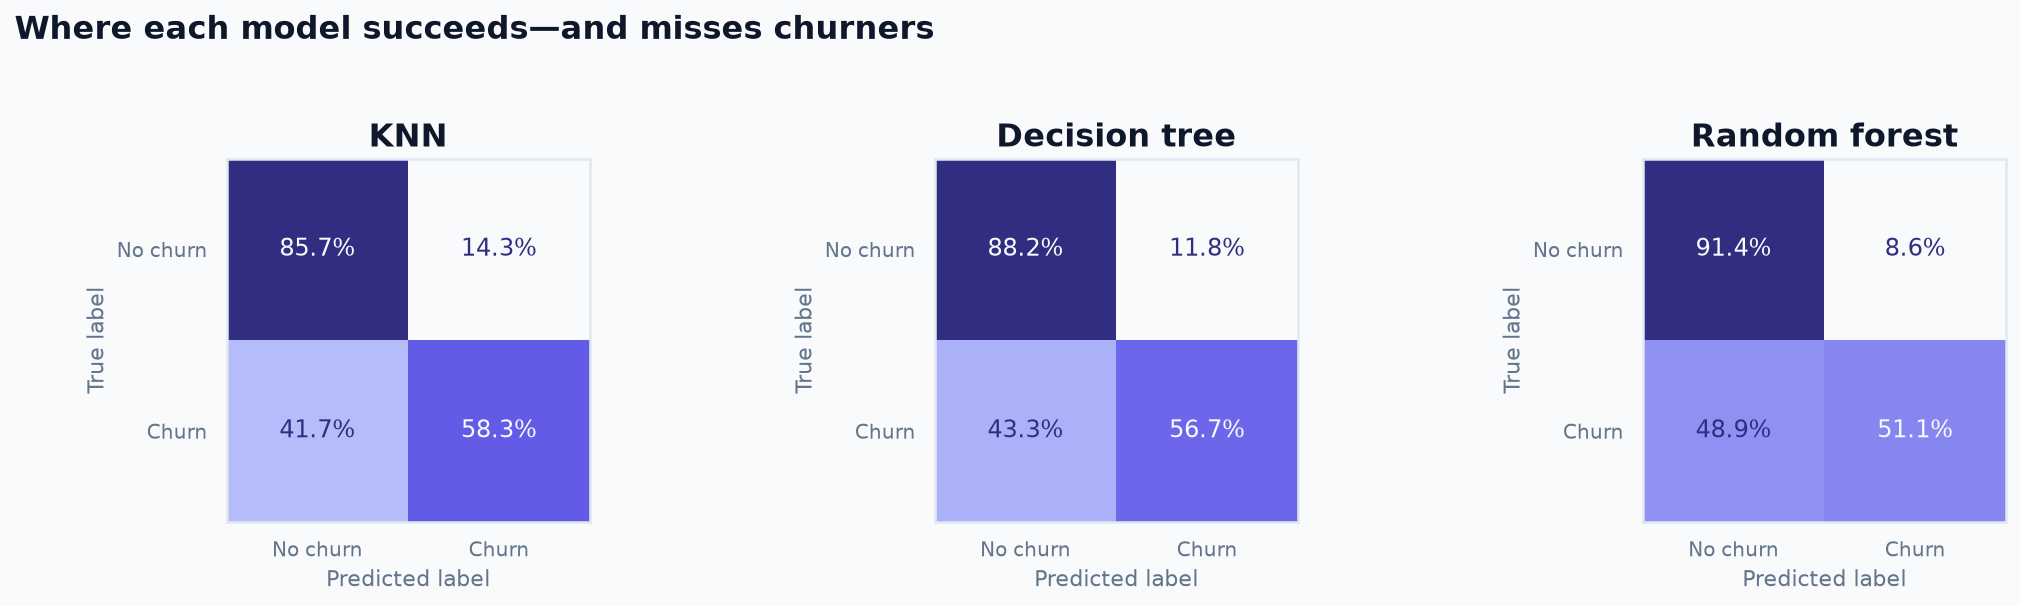

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, prediction) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, prediction, display_labels=["No churn", "Churn"],
        normalize="true", values_format=".1%", cmap=INDIGO_CMAP, ax=ax,
        colorbar=False,
    )
    ax.set_title(name)
plt.suptitle("Where each model succeeds—and misses churners", x=0.02, y=1.04, ha="left", color=INK, fontsize=16, fontweight="bold")
finish_figure(fig)

Normalized confusion matrices expose different error behavior at similar accuracy. Churn recall is especially important because a false negative is a customer the retention process fails to identify.

## 11. Algorithm introspection

### Random-forest impurity importance

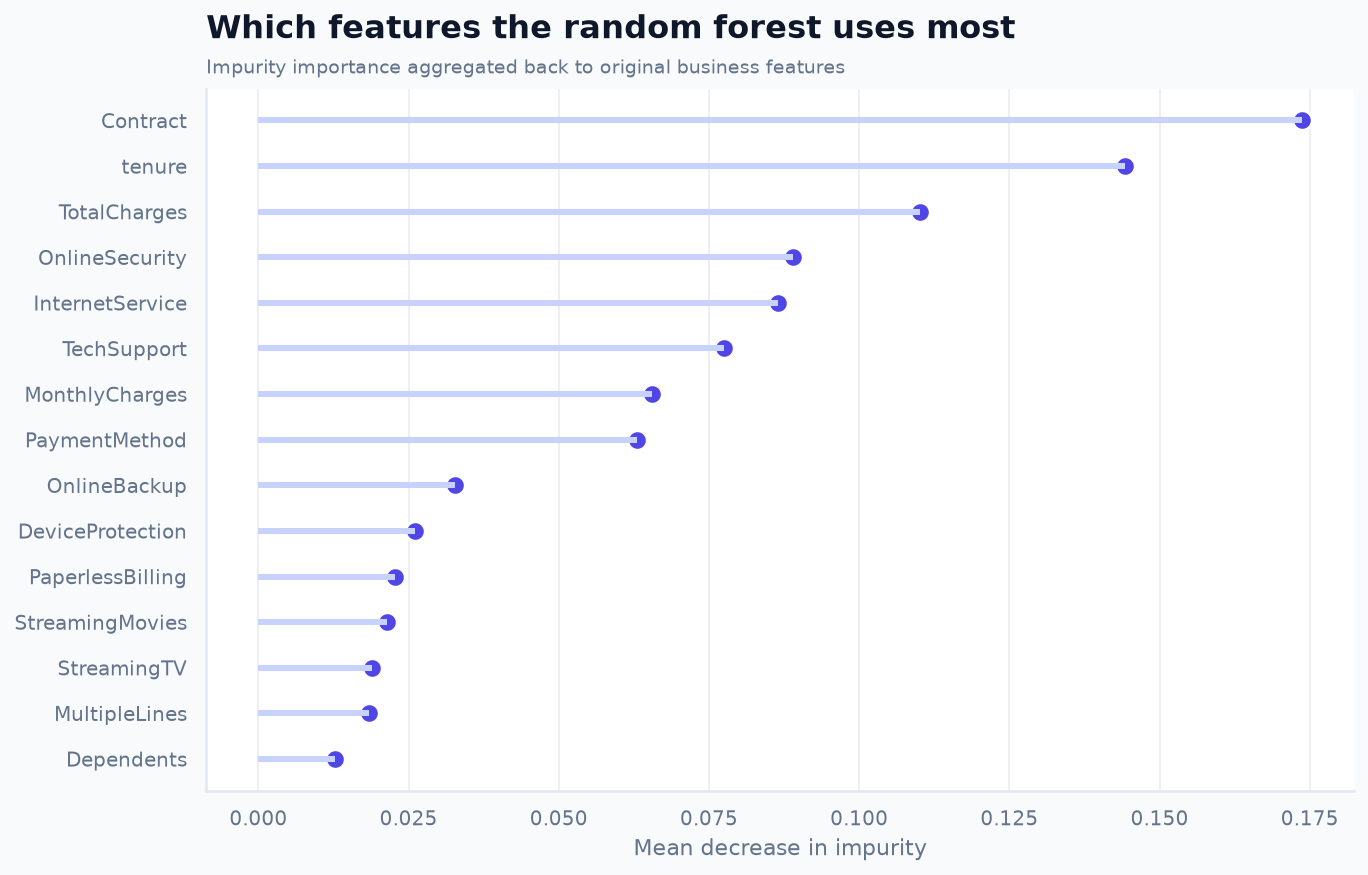

,impurity_importance
Contract,0.173729
tenure,0.144188
TotalCharges,0.110121
OnlineSecurity,0.089037
InternetService,0.086451
TechSupport,0.077511
MonthlyCharges,0.065568
PaymentMethod,0.063030
OnlineBackup,0.032736
DeviceProtection,0.026068


In [30]:
forest_preprocessor = best_forest.named_steps["preprocessor"]
encoded_names = forest_preprocessor.get_feature_names_out()
encoded_importance = pd.Series(
    best_forest.named_steps["model"].feature_importances_,
    index=encoded_names,
)

numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()
grouped_importance = {}
for name, value in encoded_importance.items():
    clean_name = name.replace("numeric__", "").replace("categorical__", "")
    original = next(
        (feature for feature in sorted(categorical_features, key=len, reverse=True)
         if clean_name.startswith(f"{feature}_")),
        clean_name,
    )
    grouped_importance[original] = grouped_importance.get(original, 0) + value

grouped_importance = pd.Series(grouped_importance, name="impurity_importance").sort_values(ascending=False)
top_grouped = grouped_importance.head(15).sort_values()
fig, ax = plt.subplots(figsize=(9.6, 6.2))
positions = np.arange(len(top_grouped))
ax.hlines(positions, 0, top_grouped.values, color="#C7D2FE", linewidth=3)
ax.scatter(top_grouped.values, positions, s=95, color=PRIMARY, edgecolor="white", linewidth=1.5)
ax.set_yticks(positions, top_grouped.index)
ax.set(xlabel="Mean decrease in impurity", ylabel="")
polish_axis(
    ax, "Which features the random forest uses most",
    "Impurity importance aggregated back to original business features",
    grid="x",
)
finish_figure(fig)
grouped_importance.head(15).to_frame()

Grouping one-hot levels returns the result to business features. Impurity importance is required for forest inspection, but it can favor continuous or high-cardinality inputs and must not be interpreted as causation.

### Permutation importance on unseen customers

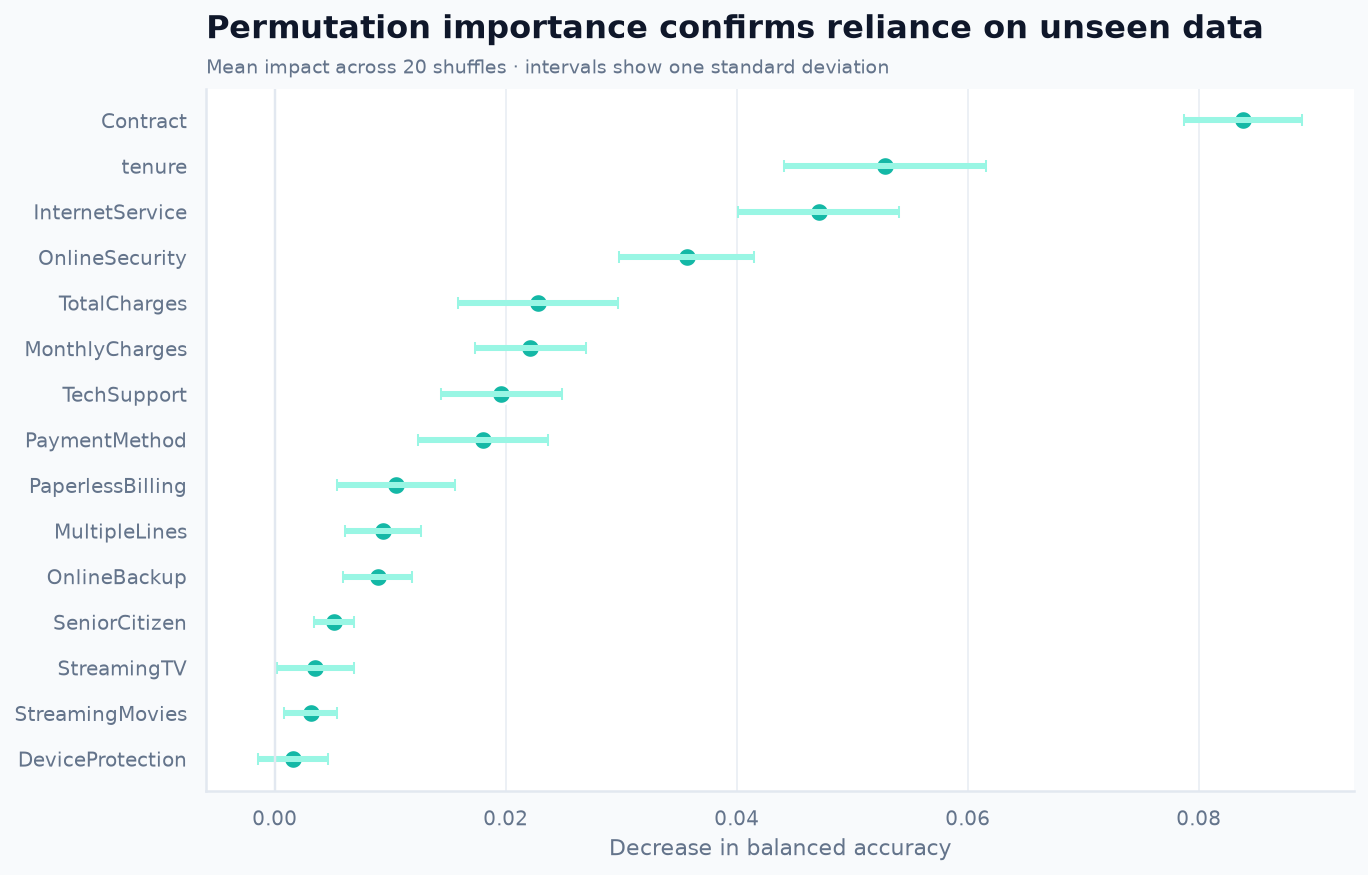

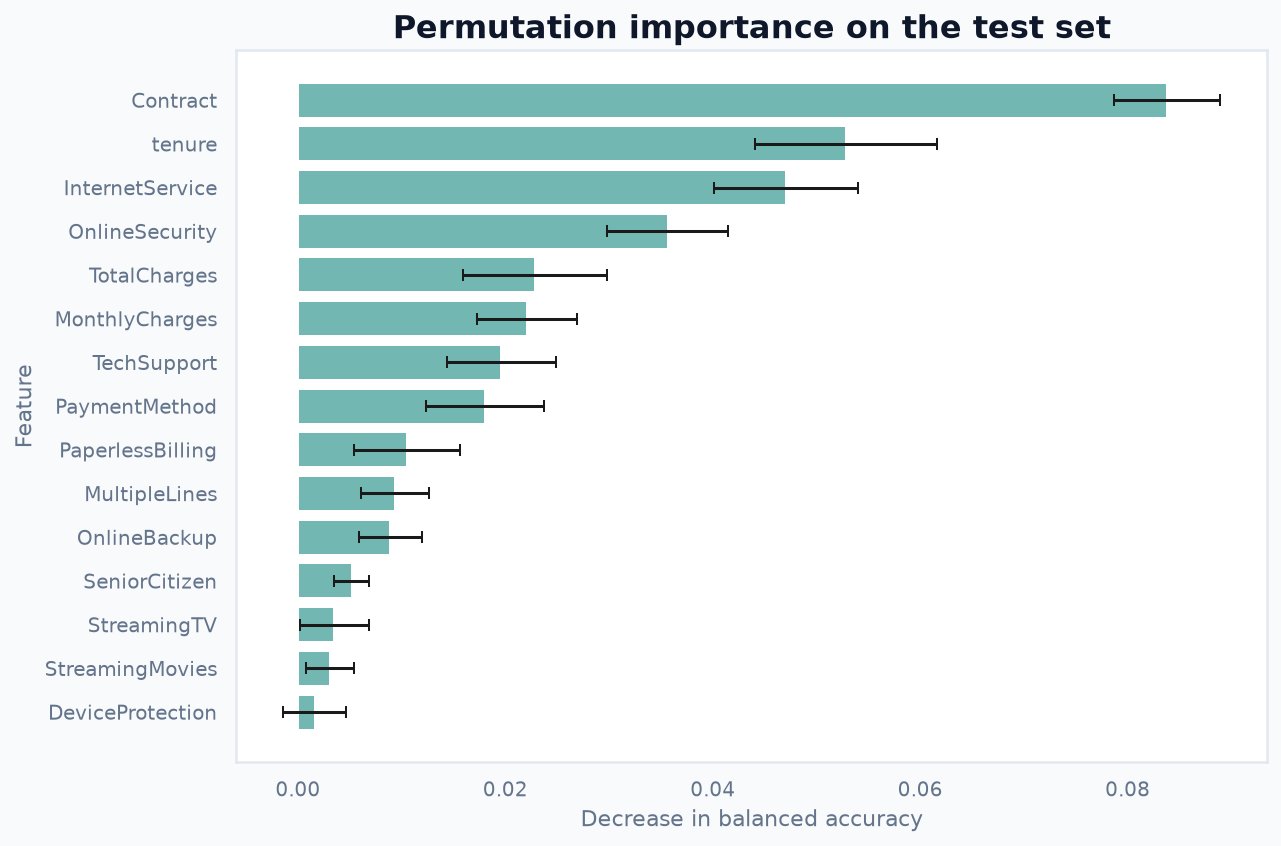

,feature,importance_mean,importance_std
14,Contract,0.083823,0.005126
4,tenure,0.052835,0.008783
7,InternetService,0.047087,0.006937
8,OnlineSecurity,0.035659,0.005842
18,TotalCharges,0.022815,0.006942
17,MonthlyCharges,0.022115,0.004808
11,TechSupport,0.019629,0.005210
16,PaymentMethod,0.018037,0.005645
15,PaperlessBilling,0.010513,0.005108
6,MultipleLines,0.009351,0.003280


In [31]:
permutation = permutation_importance(
    best_forest, X_test, y_test,
    scoring="balanced_accuracy", n_repeats=20,
    random_state=RANDOM_STATE, n_jobs=-1,
)
permutation_table = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": permutation.importances_mean,
    "importance_std": permutation.importances_std,
}).sort_values("importance_mean", ascending=False)

top_permutation = permutation_table.head(15).sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(9.6, 6.2))
positions = np.arange(len(top_permutation))
ax.errorbar(
    top_permutation["importance_mean"], positions,
    xerr=top_permutation["importance_std"],
    fmt="none", ecolor="#99F6E4", elinewidth=3, capsize=3,
)
ax.scatter(
    top_permutation["importance_mean"], positions,
    s=95, color=TEAL, edgecolor="white", linewidth=1.5,
)
ax.axvline(0, color=GRID, linewidth=1.2)
ax.set_yticks(positions, top_permutation["feature"])
ax.set(xlabel="Decrease in balanced accuracy", ylabel="")
polish_axis(
    ax, "Permutation importance confirms reliance on unseen data",
    "Mean impact across 20 shuffles · intervals show one standard deviation",
    grid="x",
)
finish_figure(fig)
permutation_table.head(15).sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    top_permutation["feature"], top_permutation["importance_mean"],
    xerr=top_permutation["importance_std"], color="#72B7B2", capsize=3,
)
ax.set(title="Permutation importance on the test set", xlabel="Decrease in balanced accuracy", ylabel="Feature")
plt.tight_layout()
plt.show()
permutation_table.head(15)

> **Interpretation note:** Permutation importance measures how much
> unseen-test performance falls when one original feature is shuffled. Error
> bars show variation across repeats. Correlated features may share importance,
> so these results describe predictive reliance rather than causation.

## 12. Error analysis

In [32]:
winning_name = final_metrics["test_accuracy"].idxmax()
winning_prediction = predictions[winning_name]
errors = model_df.loc[test_indices, ["Contract", "TenureGroup", "InternetService"]].copy()
errors["actual"] = y_test
errors["predicted"] = winning_prediction
errors["error_type"] = np.select(
    [
        errors["actual"].eq(1) & errors["predicted"].eq(0),
        errors["actual"].eq(0) & errors["predicted"].eq(1),
    ],
    ["False negative", "False positive"],
    default="Correct",
)

def segment_error_table(frame, column):
    return pd.crosstab(
        frame[column], frame["error_type"], normalize="index"
    ).reindex(columns=["Correct", "False negative", "False positive"], fill_value=0)

print("Winning model:", winning_name)
display(segment_error_table(errors, "Contract").style.format("{:.1%}"))
display(segment_error_table(errors, "TenureGroup").style.format("{:.1%}"))
display(segment_error_table(errors, "InternetService").style.format("{:.1%}"))

Winning model: Random forest


error_type,Correct,False negative,False positive
Contract,,,
Month-to-month,70.6%,17.9%,11.5%
One year,88.0%,12.0%,0.0%
Two year,97.3%,2.7%,0.0%


error_type,Correct,False negative,False positive
TenureGroup,,,
0-12 months,70.4%,14.3%,15.4%
13-24 months,76.2%,17.0%,6.8%
25-48 months,81.2%,16.8%,2.0%
49+ months,92.7%,7.3%,0.0%


error_type,Correct,False negative,False positive
InternetService,,,
DSL,84.5%,13.4%,2.1%
Fiber optic,71.9%,15.2%,12.9%
No,92.0%,8.0%,0.0%


Error tables identify where the winner misses churners or incorrectly flags loyal customers. They are diagnostic rather than additional selection criteria because examining many test subgroups can itself lead to overinterpretation.

## 13. Conclusions

In [33]:
winner = final_metrics.loc[winning_name]
print(f"Selected model: {winning_name}")
print(f"Training accuracy: {winner['train_accuracy']:.4f}")
print(f"Test accuracy: {winner['test_accuracy']:.4f}")
print(f"Churn recall: {winner['churn_recall']:.4f}")
print(f"Churn precision: {winner['churn_precision']:.4f}")
print(f"PR-AUC: {winner['pr_auc']:.4f}")
print(f"Generalization gap: {winner['train_accuracy'] - winner['test_accuracy']:.4f}")
print("\nBest parameters:")
if winning_name == "KNN":
    display(pd.Series(knn_search.best_params_, name="value").to_frame())
elif winning_name == "Decision tree":
    display(pd.Series(tree_search.best_params_, name="value").to_frame())
else:
    display(pd.Series(forest_search.best_params_, name="value").to_frame())

Selected model: Random forest
Training accuracy: 0.8348
Test accuracy: 0.8070
Churn recall: 0.5107
Churn precision: 0.6821
PR-AUC: 0.6578
Generalization gap: 0.0278

Best parameters:


,value
model__max_depth,8
model__max_features,sqrt
model__min_samples_leaf,1
model__n_estimators,200


- The dataset contains 7,043 customers and has a 26.54% churn rate.
- Short tenure, month-to-month contracts, higher monthly charges, fiber-optic
  service, and electronic-check payment are associated with higher churn.
- `customerID` was removed. Blank `TotalCharges` values belonged to zero-tenure
  customers and were set to zero.
- A small set of engineered features was evaluated through ablation.
- KNN, decision tree, and random forest were tuned with five-fold stratified
  cross-validation on the training data.
- Final train and test accuracy were measured only after parameter selection.
- Tree artifacts and two forest-importance methods support model introspection.

> **Limitation:** This fictional, point-in-time dataset demonstrates an analysis
> method. The results are neither causal evidence nor guaranteed performance for
> a real telecommunications company.